## WorldView Scene-Combination Benchmark: SpaceNet Atlanta, then UCSD

**Given N scenes, which combinations and which processing flow give the best DEM?** This notebook is the systematic version of the two-DEM comparison in [`worldview_spacenet_atlanta_mvs.ipynb`](https://asp-plot.readthedocs.io/en/latest/examples/notebooks/worldview_spacenet_atlanta_mvs.html). Every DEM is scored with `asp_plot.dem_benchmark.DEMBenchmark` against **one** ICESat-2 ATL06-SR sample per site, so every number is directly comparable.

Three axes:

1. **Convergence angle** — all ten pairs among five same-pass scenes span 5–32°. How does single-pair accuracy depend on it?
2. **Number of scenes** — a nested chain, pair ⊂ 3 ⊂ 4 ⊂ 5 scenes: does each added scene earn its cost?
3. **Processing flow** — joint multi-view triangulation vs. independent pairs merged with `dem_mosaic`, and whether merging only the well-converged pairs rescues the mosaic.

The second half repeats the experiment at a **second site** chosen to break every caveat of the first: the SpaceNet UCSD WorldView-3 archive, *multi-date* rather than same-pass, over a steep, built-up, tree-covered 3 × 3 km crop of Mount Soledad.

---

## Testbed

Five same-pass WorldView-2 scenes over Hartsfield–Jackson Atlanta International Airport (2009-12-22, SpaceNet AOI 6, public on `s3://spacenet-dataset/AOIs/AOI_6_Atlanta/`), all `wv_correct`ed and bundle-adjusted **together** (`ba/run`, five scenes), so every stereo run below shares one camera network and any DEM difference comes from the stereo strategy, not the cameras. See the MVS notebook for the download, `wv_correct`, and `bundle_adjust` steps.

| Name | CATID / tile | Along-track order | Role |
|---|---|---|---|
| nadir10 | `1030010003CAF100_P002` | 1 | |
| nadir8 | `10300100023BC100_P001` | 2 | |
| nadir13 | `1030010002B7D800_P002` | 3 | reference scene of every MVS run (crop window `5879 13107 12981 11894`) |
| nadir16 | `1030010002649200_P001` | 4 | |
| nadir21 | `1030010003127500_P001` | 5 | |

`bundle_adjust` reports the convergence angle of every image pair that had matches, which is the first axis of the experiment:

In [1]:
import os

import numpy as np
import pandas as pd

# Set the base directory for your processing
directory = "~/Desktop/asp-plot-examples/atlanta_mvs/"
directory = os.path.expanduser(directory)

SCENES = {
    "1030010003CAF100_P002": "10",
    "10300100023BC100_P001": "8",
    "1030010002B7D800_P002": "13",
    "1030010002649200_P001": "16",
    "1030010003127500_P001": "21",
}

# ba/run-convergence_angles.txt: left right 25% 50% 75% num_matches (degrees)
conv = pd.read_csv(
    f"{directory}ba/run-convergence_angles.txt",
    sep=r"\s+",
    comment="#",
    names=["left", "right", "p25", "p50", "p75", "num_matches"],
)
for col in ("left", "right"):
    conv[col] = conv[col].str.replace("_corr.tif", "", regex=False).map(SCENES)


def pair_dir(a, b):
    """stereo_pair_<A>_<B> directories (either order of the two scene names)."""
    for left, right in ((a, b), (b, a)):
        d = f"stereo_pair_{left}_{right}"
        if os.path.isdir(f"{directory}{d}"):
            return d
    return f"stereo_pair_{a}_{b}"


conv["pair"] = conv.apply(lambda r: f"{r.left}-{r.right}", axis=1)
conv["run_dir"] = conv.apply(lambda r: pair_dir(r.left, r.right), axis=1)
conv["dem_exists"] = conv["run_dir"].map(lambda d: os.path.exists(f"{directory}{d}/run-DEM.tif"))
conv = conv.sort_values("p50").reset_index(drop=True)
conv[["pair", "p50", "p25", "p75", "num_matches", "run_dir", "dem_exists"]].rename(
    columns={"p50": "convergence (deg)"}
)

,pair,convergence (deg),p25,p75,num_matches,run_dir,dem_exists
0,13-16,5.123524,4.831792,5.479853,7451,stereo_pair_13_16,True
1,16-21,5.361678,5.327280,5.394798,6201,stereo_pair_16_21,True
2,8-10,5.456345,5.099122,5.876843,7305,stereo_pair_10_8,True
3,13-21,10.507380,10.241351,10.817621,4813,stereo_pair_13_21,True
4,13-8,16.325202,15.900078,16.673266,5550,stereo_pair_13_8,True
5,8-16,21.465489,21.401535,21.518222,3707,stereo_pair_8_16,True
6,13-10,21.791530,21.786859,21.795557,4725,stereo_pair_13_10,True
7,8-21,26.834443,26.725781,26.920276,2188,stereo_pair_8_21,True
8,10-16,26.934903,26.626338,27.294847,2822,stereo_pair_10_16,True
9,10-21,32.293319,32.017714,32.622930,1860,stereo_pair_10_21,True


Ten pairs, evenly spread from 5° to 32°; three of them (5.1°, 21.8°, 26.9°) were already run for the MVS example. The match count falls with convergence, as expected.

### Crop windows for the new pairs

Every run crops the reference scene (nadir13) to the airport window and lets ASP find the corresponding region in the other image. A pair whose *left* image is not nadir13 gets its own `--left-image-crop-win` from the `bundle_adjust` match points that fall inside the nadir13 crop, padded by 100 px; nadir10's window reproduces the one used for `stereo_pair_10_16`, which validates the method.

In [2]:
from asp_plot.stereo import read_match_file

XOFF, YOFF, W, H = 5879, 13107, 12981, 11894  # nadir13 reference crop
REF = "1030010002B7D800_P002"

# The windows come from bundle_adjust's clean match files alone, so this works
# after the stereo runs' images have been cleaned up.
crops = {"13": (XOFF, YOFF, W, H)}
for cid, name in SCENES.items():
    if cid == REF:
        continue
    match_fn = f"{directory}ba/run-{REF}_corr__{cid}_corr-clean.match"
    match_df = read_match_file(match_fn)
    inwin = match_df[match_df.x1.between(XOFF, XOFF + W) & match_df.y1.between(YOFF, YOFF + H)]
    pad = 100
    x0, y0 = int(inwin.x2.min()) - pad, int(inwin.y2.min()) - pad
    x1, y1 = int(inwin.x2.max()) + pad, int(inwin.y2.max()) + pad
    crops[name] = (x0, y0, x1 - x0, y1 - y0)
    print(
        f"nadir{name:<3} {len(inwin):5d} of {len(match_df):5d} clean matches in the reference crop"
        f"  -> --left-image-crop-win {x0} {y0} {x1 - x0} {y1 - y0}"
    )

nadir10    775 of  4725 clean matches in the reference crop  -> --left-image-crop-win 5540 13223 13206 12931
nadir8     890 of  5550 clean matches in the reference crop  -> --left-image-crop-win 5461 9789 13354 12980
nadir16   1176 of  7451 clean matches in the reference crop  -> --left-image-crop-win 6083 8756 12879 11461
nadir21    785 of  4813 clean matches in the reference crop  -> --left-image-crop-win 6467 8177 12495 10687


---

## Processing

All runs use the settings of the MVS example: `asp_mgm`, `--subpixel-mode 9`, `affineepipolar`, the shared five-scene `ba/run` prefix, `point2dem --tr 1.9 --t_srs EPSG:32616 --errorimage`. Beyond the three pairs and two multi-view runs of that example, the matrix needs:

| Run | Products | Answers |
|---|---|---|
| the seven remaining pairs | `stereo_pair_13_8`, `_13_21`, `_10_8`, `_10_21`, `_8_16`, `_8_21`, `_16_21` | axis 1: NMAD vs. convergence over all ten pairs |
| `dem_mosaic` of all ten pairs / of the six pairs > 15° | `pairwise10_mosaic-DEM.tif`, `pairwise_wide6_mosaic-DEM.tif` | axis 3: the five-scene pairwise flows |
| nested quad `{13,10,16,21}` | `stereo_mvs4/` | axis 2: the 2→3→4→5 chain |
| wide-spread triple `{13,8,21}` | `stereo_mvs3_wide/` | axis 2: does *which* three scenes matter as much as how many? |
| the five scenes referenced on **nadir10** | `stereo_mvs5_ref10/` | axis 2/3: ASP matches every scene to the reference only, so a multi-view run is a star of reference-to-scene pairs — nadir13's is 5.1 / 10.5 / 16.3 / 21.8°, nadir10's 5.5 / 21.8 / 26.9 / 32.3° |
| `dem_mosaic --median` and a convergence-weighted `dem_mosaic` of all ten pairs | `pairwise10_median_mosaic-DEM.tif`, `pairwise10_convw_mosaic-DEM.tif` | axis 3: can a smarter blend replace pair selection? |
| every pair re-triangulated with `--propagate-errors`, then `dem_mosaic --weight-list <VerticalStdDev> --invert-weights` | `stereo_pair_*_err/`, `pairwise10_vstd_mosaic-DEM.tif` | axis 3: the *sfm_multiview* flow exactly as the ASP manual describes it |

---

## Scoring every DEM against one ICESat-2 sample

`DEMBenchmark` scores each candidate with the report's recipe: the cached ATL06-SR parquet replayed (no SlideRule request), ESA WorldCover water returns dropped, a gross-outlier gate at 30 NMAD from the median followed by a 3σ cut per DEM (the gate is explained in the UCSD section), and a `pc_align --compute-translation-only` of its own under `dem_benchmark/<label>/`. Coverage and triangulation error are measured inside the **common footprint** of all DEMs scored.

In [3]:
from asp_plot.dem_benchmark import DEMBenchmark

conv_of = dict(zip(conv["pair"], conv["p50"]))

candidates = {}
for _, r in conv.iterrows():
    candidates[f"pair {r.pair} ({r.p50:.1f}°)"] = f"{directory}{r.run_dir}/run-DEM.tif"
candidates.update(
    {
        "3 pairs + mosaic {13,10,16}": f"{directory}pairwise_mosaic-DEM.tif",
        "6 pairs > 15° + mosaic": f"{directory}pairwise_wide6_mosaic-DEM.tif",
        "10 pairs + mosaic": f"{directory}pairwise10_mosaic-DEM.tif",
        "10 pairs + median mosaic": f"{directory}pairwise10_median_mosaic-DEM.tif",
        "10 pairs + conv-weighted mosaic": f"{directory}pairwise10_convw_mosaic-DEM.tif",
        "10 pairs + VerticalStdDev-weighted mosaic": f"{directory}pairwise10_vstd_mosaic-DEM.tif",
        "MVS 3 {13,10,16}": f"{directory}stereo_mvs3/run-DEM.tif",
        "MVS 3 {13,8,21}": f"{directory}stereo_mvs3_wide/run-DEM.tif",
        "MVS 4 {13,10,16,21}": f"{directory}stereo_mvs4/run-DEM.tif",
        "MVS 5": f"{directory}stereo_mvs5/run-DEM.tif",
        "MVS 5 ref nadir10": f"{directory}stereo_mvs5_ref10/run-DEM.tif",
    }
)

existing = {k: v for k, v in candidates.items() if os.path.exists(v)}
pending = [k for k in candidates if k not in existing]
print(f"{len(existing)} of {len(candidates)} candidates on disk; pending: {pending}\n")

bench = DEMBenchmark(
    directory=directory,
    dems=existing,
    parquet=f"{directory}atl06sr_all.parquet",
    reference="MVS 5",
    title="Atlanta WV2 2009-12-22: same-pass scene combinations",
)
stats = bench.run()
stats.drop(columns=["dem_fn", "gsd_m", "north_shift_m", "east_shift_m", "down_shift_m"]).round(2)

21 of 21 candidates on disk; pending: []


=== [1/21] pair 13-16 (5.1°): /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/stereo_pair_13_16/run-DEM.tif


Reusing ICESat-2 ATL06-SR points for 'all' from: /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/atl06sr_all.parquet
Filtering ATL06-SR all


  Outlier filter (3σ): all 7937 → 7770 (removed 167)
  7004 altimetry points: median +0.49 m, NMAD 1.54 m
  Reusing pc_align output in /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/dem_benchmark/pair_13-16_5.1/pc_align

Writing out: /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/dem_benchmark/pair_13-16_5.1/run-DEM_pc_align_translated.tif



  after pc_align (|t| = 0.63 m): median +0.27 m, NMAD 1.54 m



=== [2/21] pair 16-21 (5.4°): /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/stereo_pair_16_21/run-DEM.tif


...

Reusing ICESat-2 ATL06-SR points for 'all' from: /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/atl06sr_all.parquet
Filtering ATL06-SR all


  Outlier filter (3σ): all 7937 → 7654 (removed 283)
  7124 altimetry points: median +0.17 m, NMAD 0.58 m
  Reusing pc_align output in /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/dem_benchmark/MVS_5_ref_nadir10/pc_align



Writing out: /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/dem_benchmark/MVS_5_ref_nadir10/run-DEM_pc_align_translated.tif



  after pc_align (|t| = 0.60 m): median +0.18 m, NMAD 0.58 m


,label,valid_pct,valid_area_km2,ie_median_m,ie_nmad_m,n_points,dh_median_m,dh_nmad_m,dh_rmse_m,translation_m,dh_aligned_median_m,dh_aligned_nmad_m,dh_aligned_rmse_m,vs_ref_median_m,vs_ref_nmad_m
0,pair 13-16 (5.1°),95.51,36.28,0.07,0.06,7004,0.49,1.54,2.60,0.63,0.27,1.54,2.57,-0.27,1.06
1,pair 16-21 (5.4°),98.23,37.32,0.07,0.06,7295,-1.46,1.54,3.00,1.69,-0.16,1.52,2.58,1.62,1.05
2,pair 8-10 (5.5°),97.25,36.94,0.07,0.06,7230,0.83,1.64,2.80,0.95,0.11,1.65,2.71,-0.59,1.15
3,pair 13-21 (10.5°),96.69,36.73,0.10,0.08,7023,-0.33,1.05,2.25,0.78,0.15,1.05,2.23,0.49,0.56
4,pair 13-8 (16.3°),95.68,36.35,0.10,0.08,6960,0.01,0.85,2.14,0.62,0.24,0.84,2.15,0.09,0.43
5,pair 8-16 (21.5°),95.97,36.46,0.08,0.07,6980,0.20,0.72,2.06,0.61,0.18,0.72,2.05,-0.11,0.34
6,pair 13-10 (21.8°),95.58,36.31,0.11,0.09,6876,0.29,0.70,2.09,0.61,0.18,0.70,2.07,-0.20,0.28
7,pair 8-21 (26.8°),95.14,36.14,0.07,0.06,6853,-0.09,0.64,1.92,0.64,0.17,0.63,1.93,0.18,0.28
8,pair 10-16 (26.9°),95.00,36.09,0.08,0.07,6852,0.40,0.63,1.96,0.63,0.16,0.63,1.90,-0.29,0.28
9,pair 10-21 (32.3°),94.40,35.86,0.09,0.08,6807,0.12,0.60,1.94,0.98,0.21,0.60,1.94,-0.02,0.29


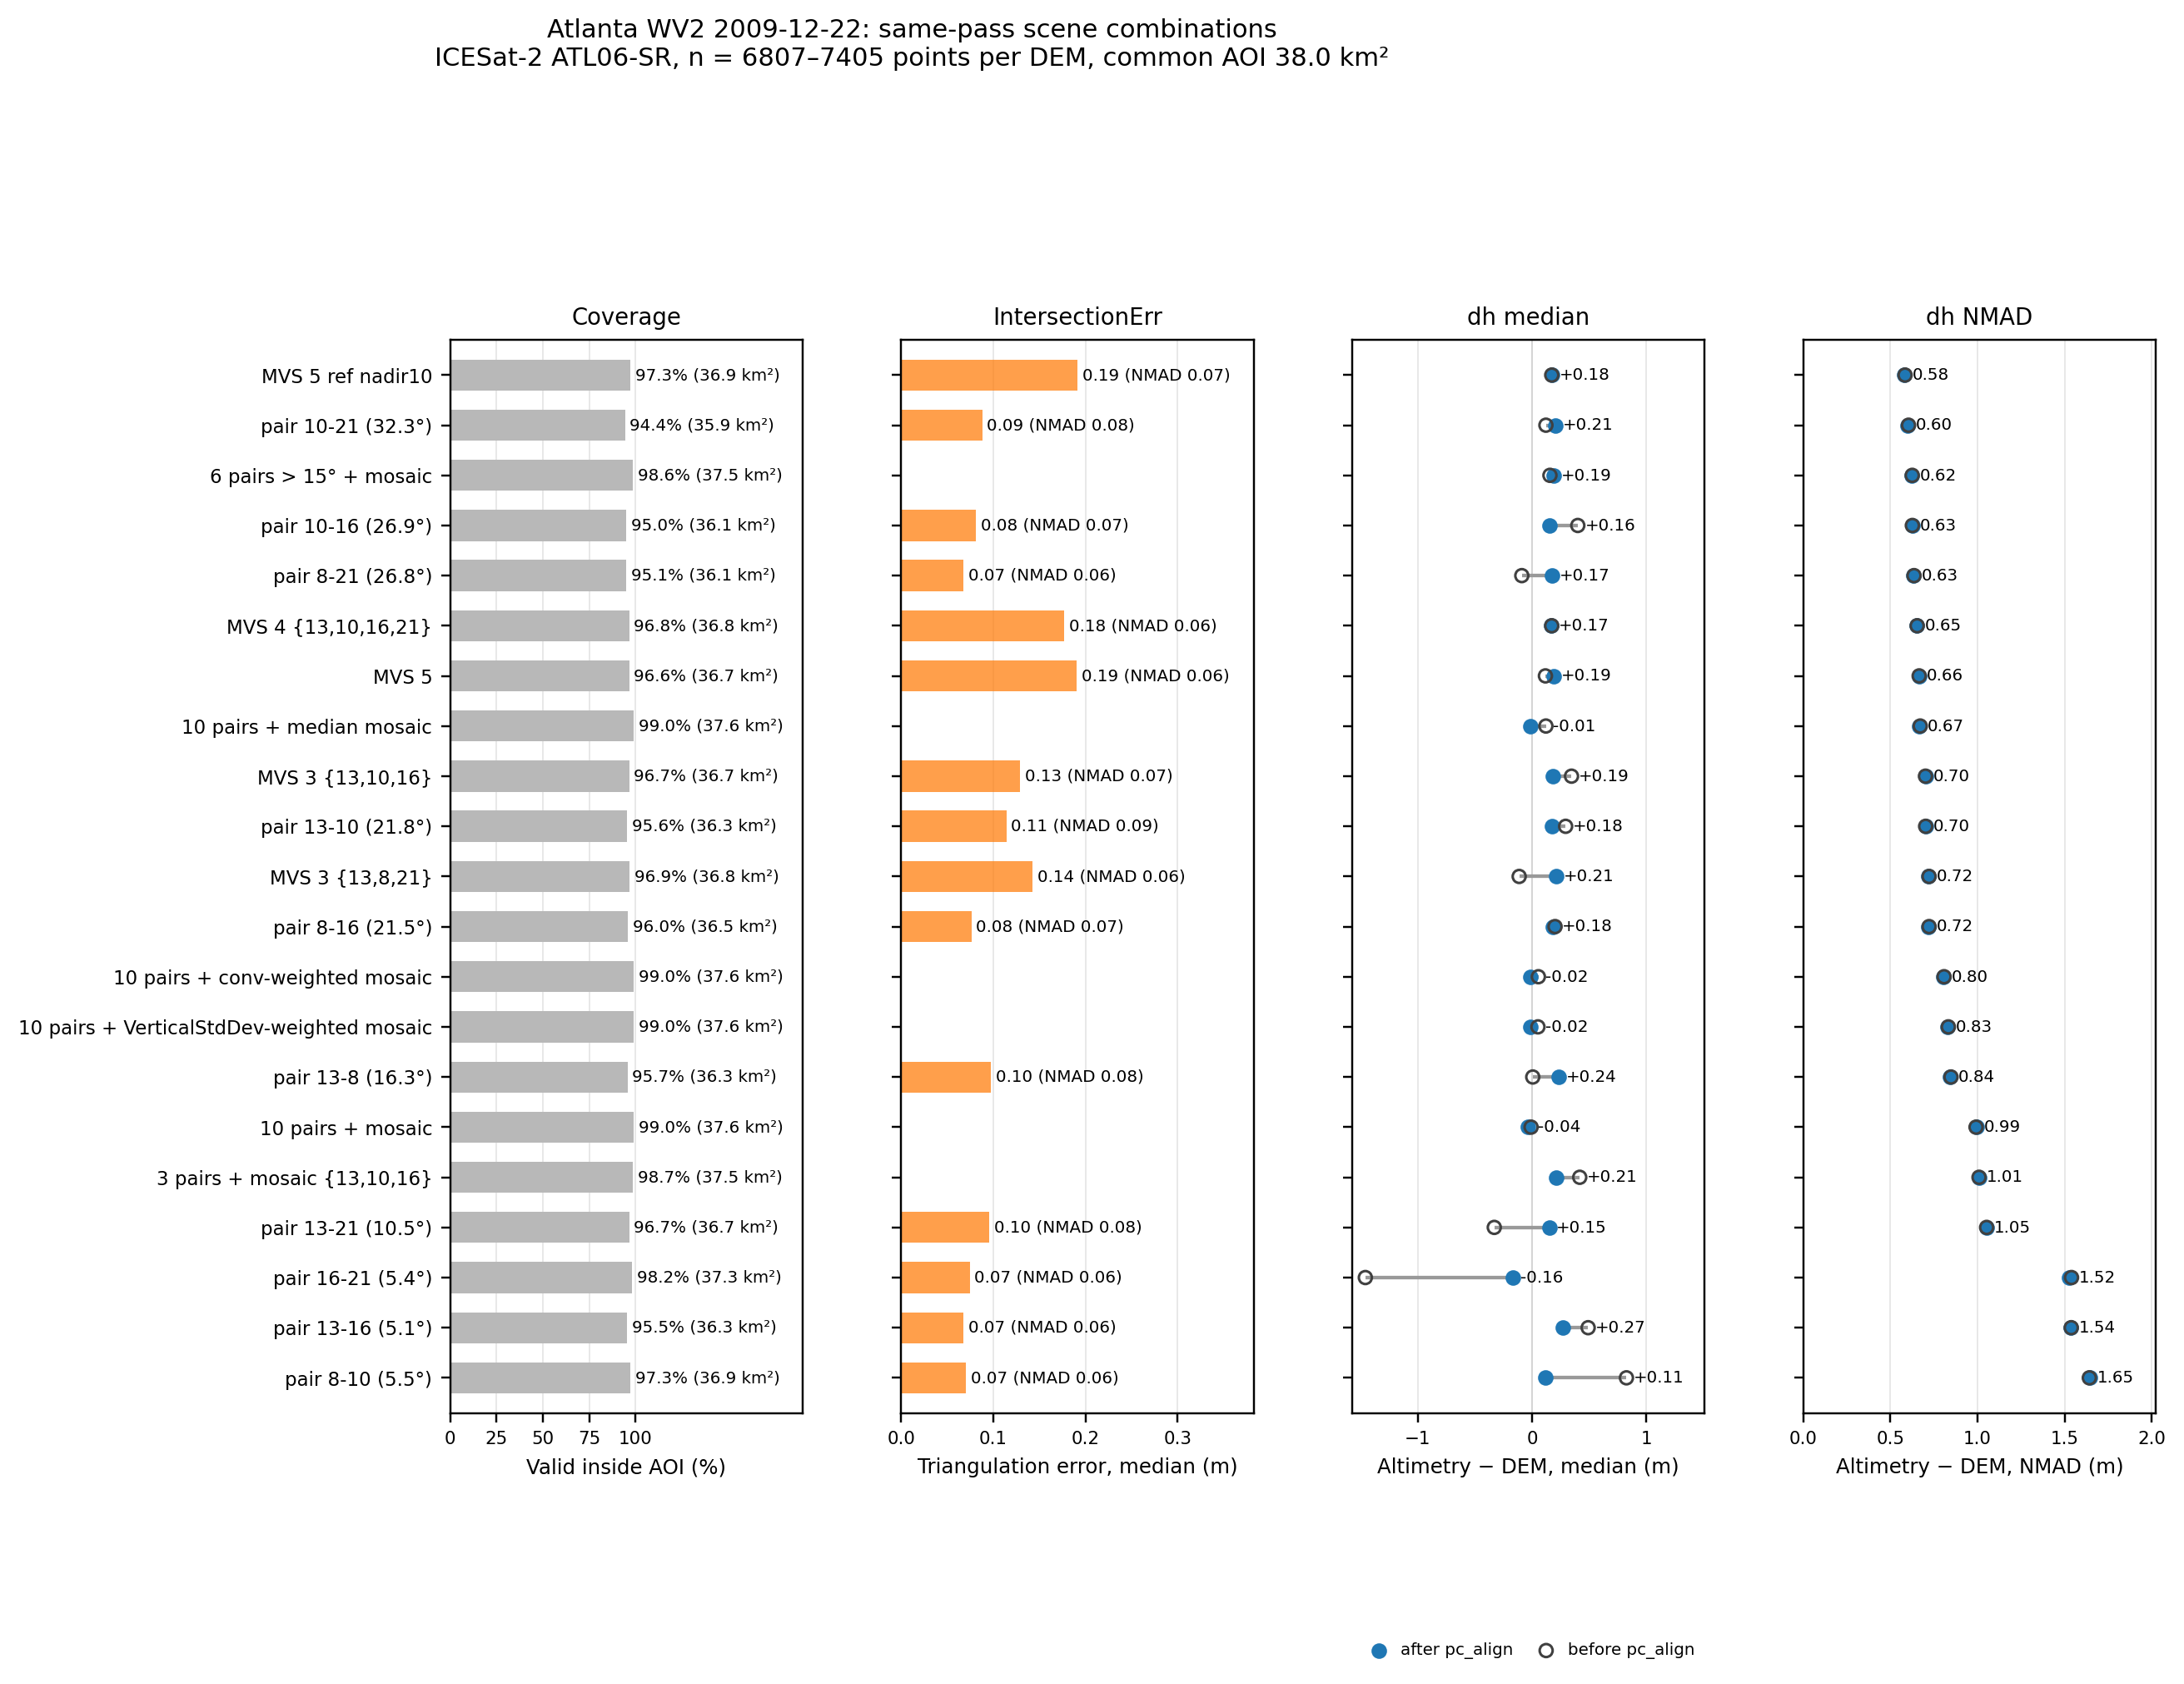

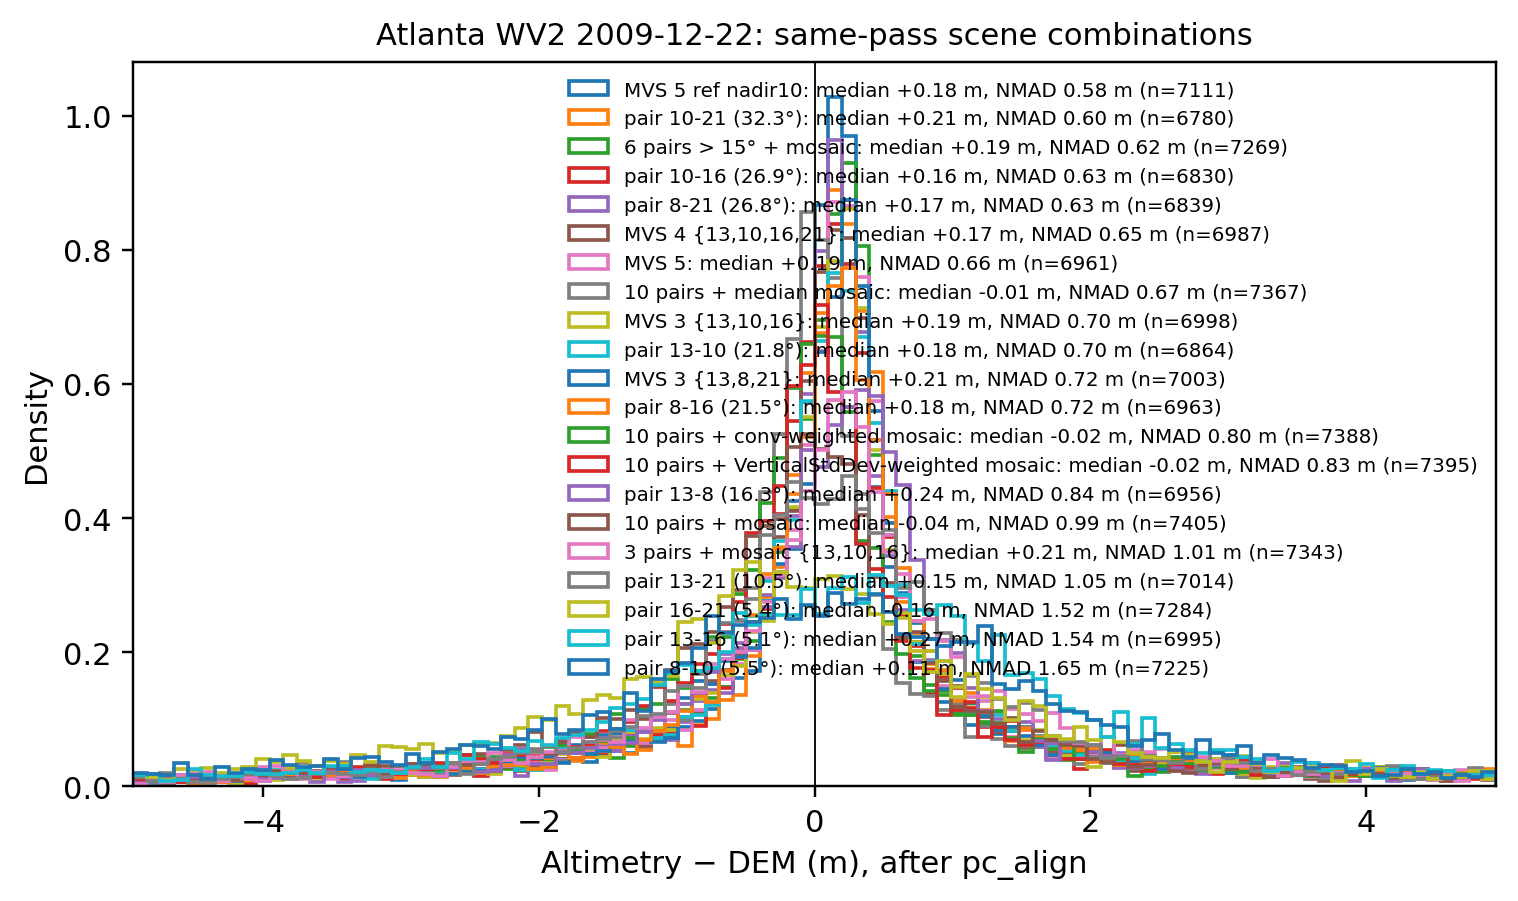

In [4]:
_ = bench.summary_plot()
_ = bench.histogram_plot()

---

## Axis 1 — single-pair accuracy vs. convergence angle

Each point is one pair, scored after its own `pc_align` translation (the translation removes bias and cannot change NMAD, so NMAD is the fair single-pair number). The 20–30° rule of thumb used in the scene-selection notebook is shaded.

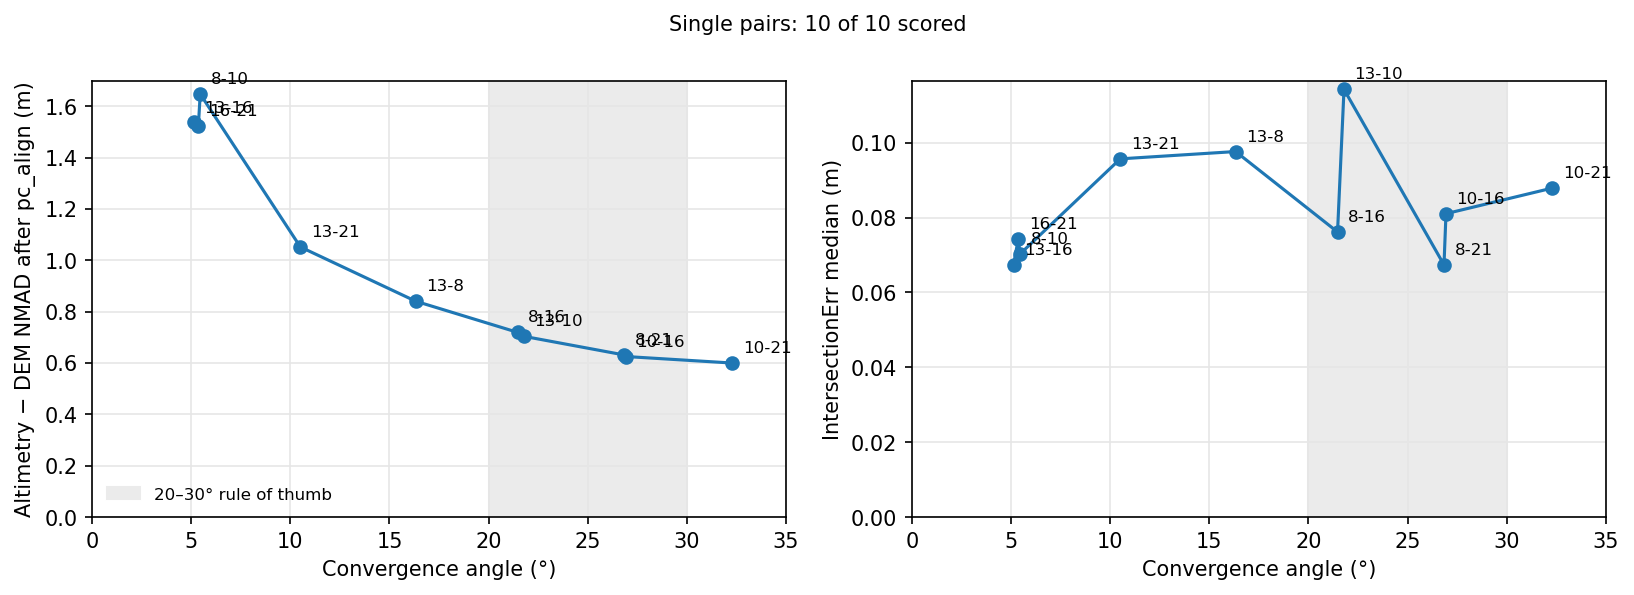

In [5]:
import matplotlib.pyplot as plt

by = stats.set_index("label")
pairs = by[by.index.str.startswith("pair ")].copy()
pairs["convergence"] = [conv_of[lbl.split()[1]] for lbl in pairs.index]
pairs = pairs.sort_values("convergence")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=150)
for ax, col, ylabel in (
    (axes[0], "dh_aligned_nmad_m", "Altimetry − DEM NMAD after pc_align (m)"),
    (axes[1], "ie_median_m", "IntersectionErr median (m)"),
):
    ax.axvspan(20, 30, color="0.92", zorder=0, label="20–30° rule of thumb")
    ax.plot(pairs["convergence"], pairs[col], "o-", color="tab:blue")
    for c, v, lbl in zip(pairs["convergence"], pairs[col], pairs.index):
        ax.annotate(lbl.split()[1], (c, v), textcoords="offset points", xytext=(5, 5), fontsize=8)
    ax.set_xlabel("Convergence angle (°)")
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, 35)
    ax.set_ylim(bottom=0)
    ax.grid(color="0.9")
axes[0].legend(fontsize=8, frameon=False)
fig.suptitle(f"Single pairs: {len(pairs)} of 10 scored" + (" (rest pending)" if len(pairs) < 10 else ""), fontsize=10)
fig.tight_layout()

---

## Axis 2 — does each added scene earn its cost?

A nested chain, so each step adds exactly one scene to the previous run: pair 13-10 (21.8°) → MVS {13,10,16} → MVS {13,10,16,21} → MVS {13,10,16,21,8}. The wide-spread triple {13,8,21} is plotted alongside as a check that *which* three scenes matters, not only how many.

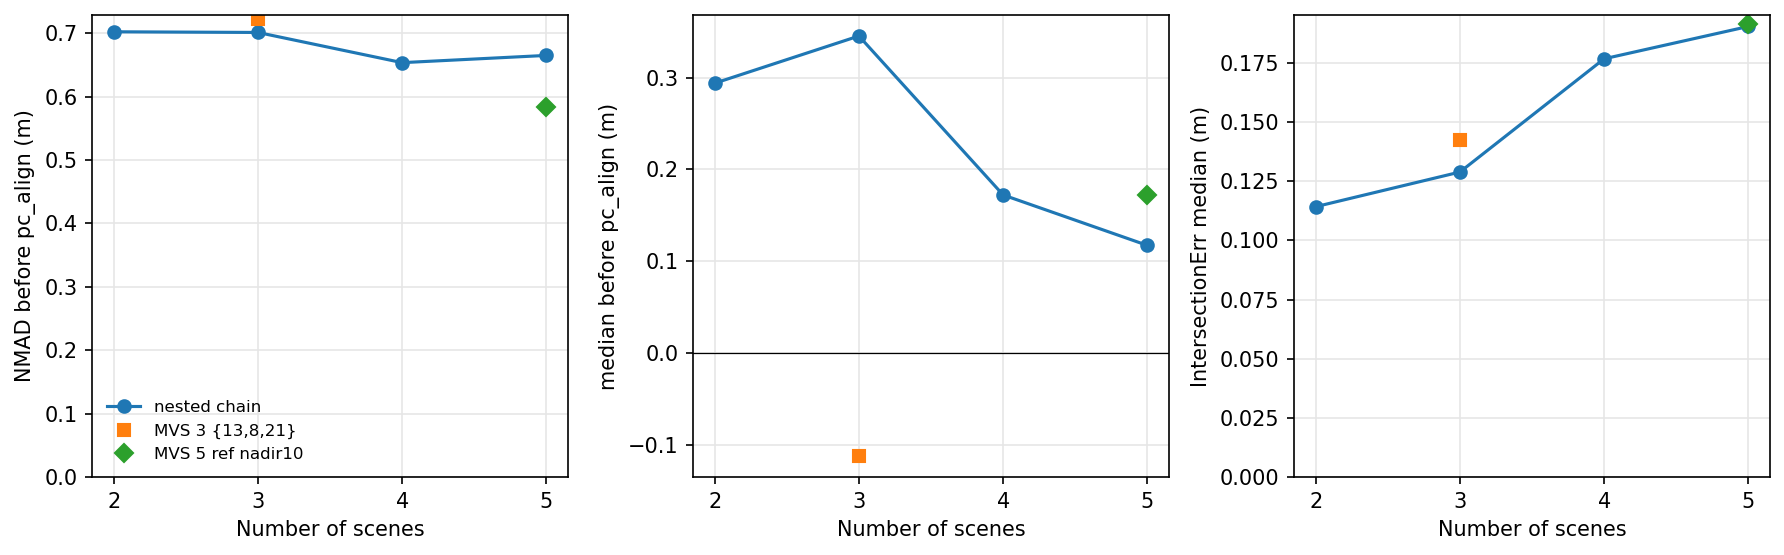

In [6]:
chain = [
    ("pair 13-10 (21.8°)", 2),
    ("MVS 3 {13,10,16}", 3),
    ("MVS 4 {13,10,16,21}", 4),
    ("MVS 5", 5),
]
present = [(lbl, n) for lbl, n in chain if lbl in by.index]
missing = [lbl for lbl, _ in chain if lbl not in by.index]
if missing:
    print("pending:", missing)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), dpi=150)
for ax, col, ylabel in (
    (axes[0], "dh_nmad_m", "NMAD before pc_align (m)"),
    (axes[1], "dh_median_m", "median before pc_align (m)"),
    (axes[2], "ie_median_m", "IntersectionErr median (m)"),
):
    ax.plot([n for _, n in present], [by.loc[lbl, col] for lbl, _ in present], "o-", color="tab:blue", label="nested chain")
    if "MVS 3 {13,8,21}" in by.index:
        ax.plot([3], [by.loc["MVS 3 {13,8,21}", col]], "s", color="tab:orange", label="MVS 3 {13,8,21}")
    if "MVS 5 ref nadir10" in by.index:
        ax.plot([5], [by.loc["MVS 5 ref nadir10", col]], "D", color="tab:green", label="MVS 5 ref nadir10")
    ax.set_xticks([2, 3, 4, 5])
    ax.set_xlabel("Number of scenes")
    ax.set_ylabel(ylabel)
    ax.grid(color="0.9")
    if col == "dh_median_m":
        ax.axhline(0, color="k", lw=0.6)
    else:
        ax.set_ylim(bottom=0)  # spreads and errors are anchored at zero, as in summary_plot
axes[0].legend(fontsize=8, frameon=False)
fig.tight_layout()

---

## Axis 3 — joint triangulation vs. pairwise + mosaic

The same scenes processed two ways: the joint triangulation with nadir13 and with nadir10 as reference, against five blends of the ten pairs — `dem_mosaic`'s default weighted average, only the six pairs above 15°, the median, a convergence-angle weighting, and the propagated-`VerticalStdDev` weighting the ASP manual's *Multiview reconstruction* section prescribes. The blends ask whether the mosaic's problem is *averaging*, or *averaging bad pairs in*.

In [7]:
flows = [
    ("3 scenes", "MVS 3 {13,10,16}", "3 pairs + mosaic {13,10,16}"),
    ("5 scenes", "MVS 5", "10 pairs + mosaic"),
    ("5 scenes, > 15° only", "MVS 5", "6 pairs > 15° + mosaic"),
    ("5 scenes, median blend", "MVS 5", "10 pairs + median mosaic"),
    ("5 scenes, conv-weighted blend", "MVS 5", "10 pairs + conv-weighted mosaic"),
    ("5 scenes, VerticalStdDev-weighted blend", "MVS 5", "10 pairs + VerticalStdDev-weighted mosaic"),
    ("5 scenes, reference nadir10", "MVS 5 ref nadir10", "6 pairs > 15° + mosaic"),
]
cols = ["valid_pct", "ie_median_m", "n_points", "dh_median_m", "dh_nmad_m", "dh_aligned_median_m", "dh_aligned_nmad_m"]
rows = []
for scenes, mvs, mosaic in flows:
    for flow, lbl in (("MVS", mvs), ("pairwise + mosaic", mosaic)):
        if lbl in by.index:
            rows.append({"scenes": scenes, "flow": flow, "DEM": lbl} | by.loc[lbl, cols].to_dict())
        else:
            rows.append({"scenes": scenes, "flow": flow, "DEM": f"{lbl} (pending)"})
pd.DataFrame(rows).set_index(["scenes", "flow"]).round(2)

DEM  \
scenes                                  flow                                                           
3 scenes                                MVS                                         MVS 3 {13,10,16}   
                                        pairwise + mosaic                3 pairs + mosaic {13,10,16}   
5 scenes                                MVS                                                    MVS 5   
                                        pairwise + mosaic                          10 pairs + mosaic   
5 scenes, > 15° only                    MVS                                                    MVS 5   
                                        pairwise + mosaic                     6 pairs > 15° + mosaic   
5 scenes, median blend                  MVS                                                    MVS 5   
                                        pairwise + mosaic                   10 pairs + median mosaic   
5 scenes, conv-weighted blend           MVS                                                    MVS 5   
                                        pairwise + mosaic            10 pairs + conv-weighted mosaic   
5 scenes, VerticalStdDev-weighted blend MVS                                                    MVS 5   
                                        pairwise + mosaic  10 pairs + VerticalStdDev-weighted mosaic   
5 scenes, reference nadir10             MVS                                        MVS 5 ref nadir10   
                                        pairwise + mosaic                     6 pairs > 15° + mosaic   

                                                           valid_pct  \
scenes                                  flow                           
3 scenes                                MVS                    96.71   
                                        pairwise + mosaic      98.71   
5 scenes                                MVS                    96.61   
                                        pairwise + mosaic      99.03   
5 scenes, > 15° only                    MVS                    96.61   
                                        pairwise + mosaic      98.59   
5 scenes, median blend                  MVS                    96.61   
                                        pairwise + mosaic      99.03   
5 scenes, conv-weighted blend           MVS                    96.61   
                                        pairwise + mosaic      99.03   
5 scenes, VerticalStdDev-weighted blend MVS                    96.61   
                                        pairwise + mosaic      99.03   
5 scenes, reference nadir10             MVS                    97.25   
                                        pairwise + mosaic      98.59   

                                                           ie_median_m  \
scenes                                  flow                             
3 scenes                                MVS                       0.13   
                                        pairwise + mosaic          NaN   
5 scenes                                MVS                       0.19   
                                        pairwise + mosaic          NaN   
5 scenes, > 15° only                    MVS                       0.19   
                                        pairwise + mosaic          NaN   
5 scenes, median blend                  MVS                       0.19   
                                        pairwise + mosaic          NaN   
5 scenes, conv-weighted blend           MVS                       0.19   
                                        pairwise + mosaic          NaN   
5 scenes, VerticalStdDev-weighted blend MVS                       0.19   
                                        pairwise + mosaic          NaN   
5 scenes, reference nadir10             MVS                       0.19   
                                        pairwise + mosaic          NaN   

                                                           n_points  \
scenes                 

---

## Takeaways

Twenty-one DEMs from the same five scenes, the same cameras and the same ICESat-2 sample. After `pc_align` every median lands at −0.16 to +0.27 m and no NMAD moves, so the post-alignment NMAD is the number quoted below. A paired bootstrap over whole ICESat-2 tracks (see part 2) supports this ranking: the best DEM ranks first in 99 % of replicates.

**Axis 1 — for a single pair, convergence angle is the whole story.** NMAD falls monotonically from 1.5–1.65 m at 5° to 1.05 m at 10.5°, 0.84 m at 16°, 0.70 m at 22°, 0.63 m at 27° and 0.60 m at 32°, with no sign of matching degrading at the wide end. The 20–30° rule of thumb is where the curve flattens: the first ten degrees cost 0.9 m, the last ten buy 0.1 m. IntersectionErr says none of this — it is 0.07–0.11 m for every pair and *lowest* for the three worst, because a narrow pair's rays intersect precisely at the wrong height.

**Axis 2 — more scenes do not make a better DEM; the *reference* does.** The nested chain pair 13-10 → MVS 3 → MVS 4 → MVS 5 goes 0.70 → 0.70 → 0.65 → 0.66 m. Extra scenes buy less bias (the pre-alignment median shrinks from +0.29 to +0.12 m), not less spread, and the wide-spread triple {13,8,21} (0.72 m) is no better than the close one (0.70 m).

The same five scenes referenced on **nadir10** instead of nadir13 score **0.58 m, the best DEM of the twenty-one**, with more coverage (97.3 %) than any pair. The reason is in ASP's source: a multi-view run is N−1 ordinary stereo pairs of the *first image with each other image*, never scene-to-scene, followed by an unweighted least-squares intersection of the valid rays at each reference pixel. A five-scene run is therefore a *star* of reference-to-scene pairs, and its quality is the quality of that star. nadir13, in the middle of the pass, has a star of 5.1, 10.5, 16.3 and 21.8°: one pair above 20°. nadir10, at the end of the pass, has 5.5, 21.8, 26.9 and 32.3°: three above 20°, including the two widest pairs in the data set.

**Axis 3 — pairwise + mosaic beats the joint triangulation only if the weak pairs are kept *out*, and weighting is not enough.** Five blends of the same ten pairs:

| blend of all ten pairs | NMAD (m) | what it does with a 5° pair |
|---|---|---|
| default weighted average | 0.99 | full weight |
| weighted by convergence angle | 0.80 | ~⅓ the weight of a 15° pair |
| weighted by propagated `VerticalStdDev` (the ASP manual's recipe) | 0.83 | the same, in effect |
| median | 0.67 | ignored wherever it is the outlier |
| only the six pairs above 15°, default average | **0.62** | excluded |

The two weighted averages are the *sfm_multiview* flow as the ASP manual prescribes it, and they get only halfway: the propagated vertical uncertainty is ~30 m for a 16° pair and nearly constant across the scene, so it is a convergence weight by another name, and a weighted *mean* can only shrink a bad DEM, not exclude it. The median can, and ties MVS 5 with no pair selection and the highest coverage of anything (99.0 %). Leaving the weak pairs out entirely is better still. `dem_mosaic`'s problem was never averaging; it was averaging weak pairs in.

**So, is multi-view "worse"?** Not as stated. The joint triangulation is the more robust default — it cannot be ruined by a bad pair the way an unfiltered mosaic can (0.66 vs. 0.99 m), it has the lowest bias, and it is one seamless cloud from one run — but it is capped by the reference star. Chosen well, it is the best result here (0.58 m), ahead of the curated mosaic (0.62 m) and the widest single pair (0.60 m). Both flows are limited by convergence angle; they differ in whether you control it by choosing the reference or by choosing the pairs.

**Practical rules from this site** (same-pass WorldView over flat terrain):
1. For a multi-view run, put a scene at one *end* of the pass first, not the middle: it gives the widest star.
2. For a pairwise flow, drop pairs below ~15° rather than down-weighting them; if pairs cannot be vetted, blend with `--median`.
3. Do not read IntersectionErr as a quality ranking, in either flow.

**Caveats.** One flat, urban, same-pass site, one 38 km² footprint, one altimetry sample. The convergence curve and the reference-star mechanism are the parts that should carry over, since one is geometry and the other is code; the next section tests exactly that. An independent check against NGS survey monuments and FAA runway ends (via `groundcontrol`) ranked the MVS 5 and 3-pair mosaic DEMs the same way. `multi_stereo --mode dem_mosaic`, ASP's own pairwise flow, was not in the 3.8.0-alpha build used here and remains untested.

---

## Second site — UCSD: multi-date WorldView-3 over steep urban terrain

The Atlanta caveats name four things that could reorder the table: steep terrain, vegetation, a multi-date stack, a different sensor. The [SpaceNet UCSD](https://spacenet.ai/core3d/) archive supplies all four at once: its 35 WorldView-3 scenes are **35 separate collects** between 2014-10-27 and 2016-02-20, so any N-scene run is multi-date stereo with weeks to months between images. That is the regime in which the ASP manual calls multi-view stereo *discouraged* and recommends pairwise stereo blended with `dem_mosaic`. The site is the [UCSD stereo example](https://asp-plot.readthedocs.io/en/latest/examples/notebooks/worldview_spacenet_ucsd_stereo.html)'s, but not its crop, which has the ocean in it.

**Crop.** Chosen first, from terrain alone, inside the footprint common to all 35 scenes. Three 3 × 3 km candidates are compared on Copernicus 30 m relief and slope, ESA WorldCover 2021 land cover, and ICESat-2 ATL06-SR ground points. **Crop A, Mount Soledad**, wins on every terrain axis: the summit, canyon walls dropping to Rose Canyon and the I-5 interchange, and hillside housing on every aspect.

| crop (3 × 3 km, UTM 11N) | relief (m) | slope > 15° | built-up | tree | ICESat-2 ground pts / tracks |
|---|---|---|---|---|---|
| **A Mount Soledad** `476000 3632000 479000 3635000` | 244 | 30 % | 45 % | 45 % | 1157 / 3 |
| B campus + canyons | 139 | 23 % | 45 % | 30 % | 1255 / 3 |
| C Rose Canyon + UTC | 83 | 10 % | 65 % | 25 % | 2563 / 3 |
| the stereo example's ROI, for reference | 146 | 12 % | 54 % | 26 % | 1451 / 2, 10 % water |

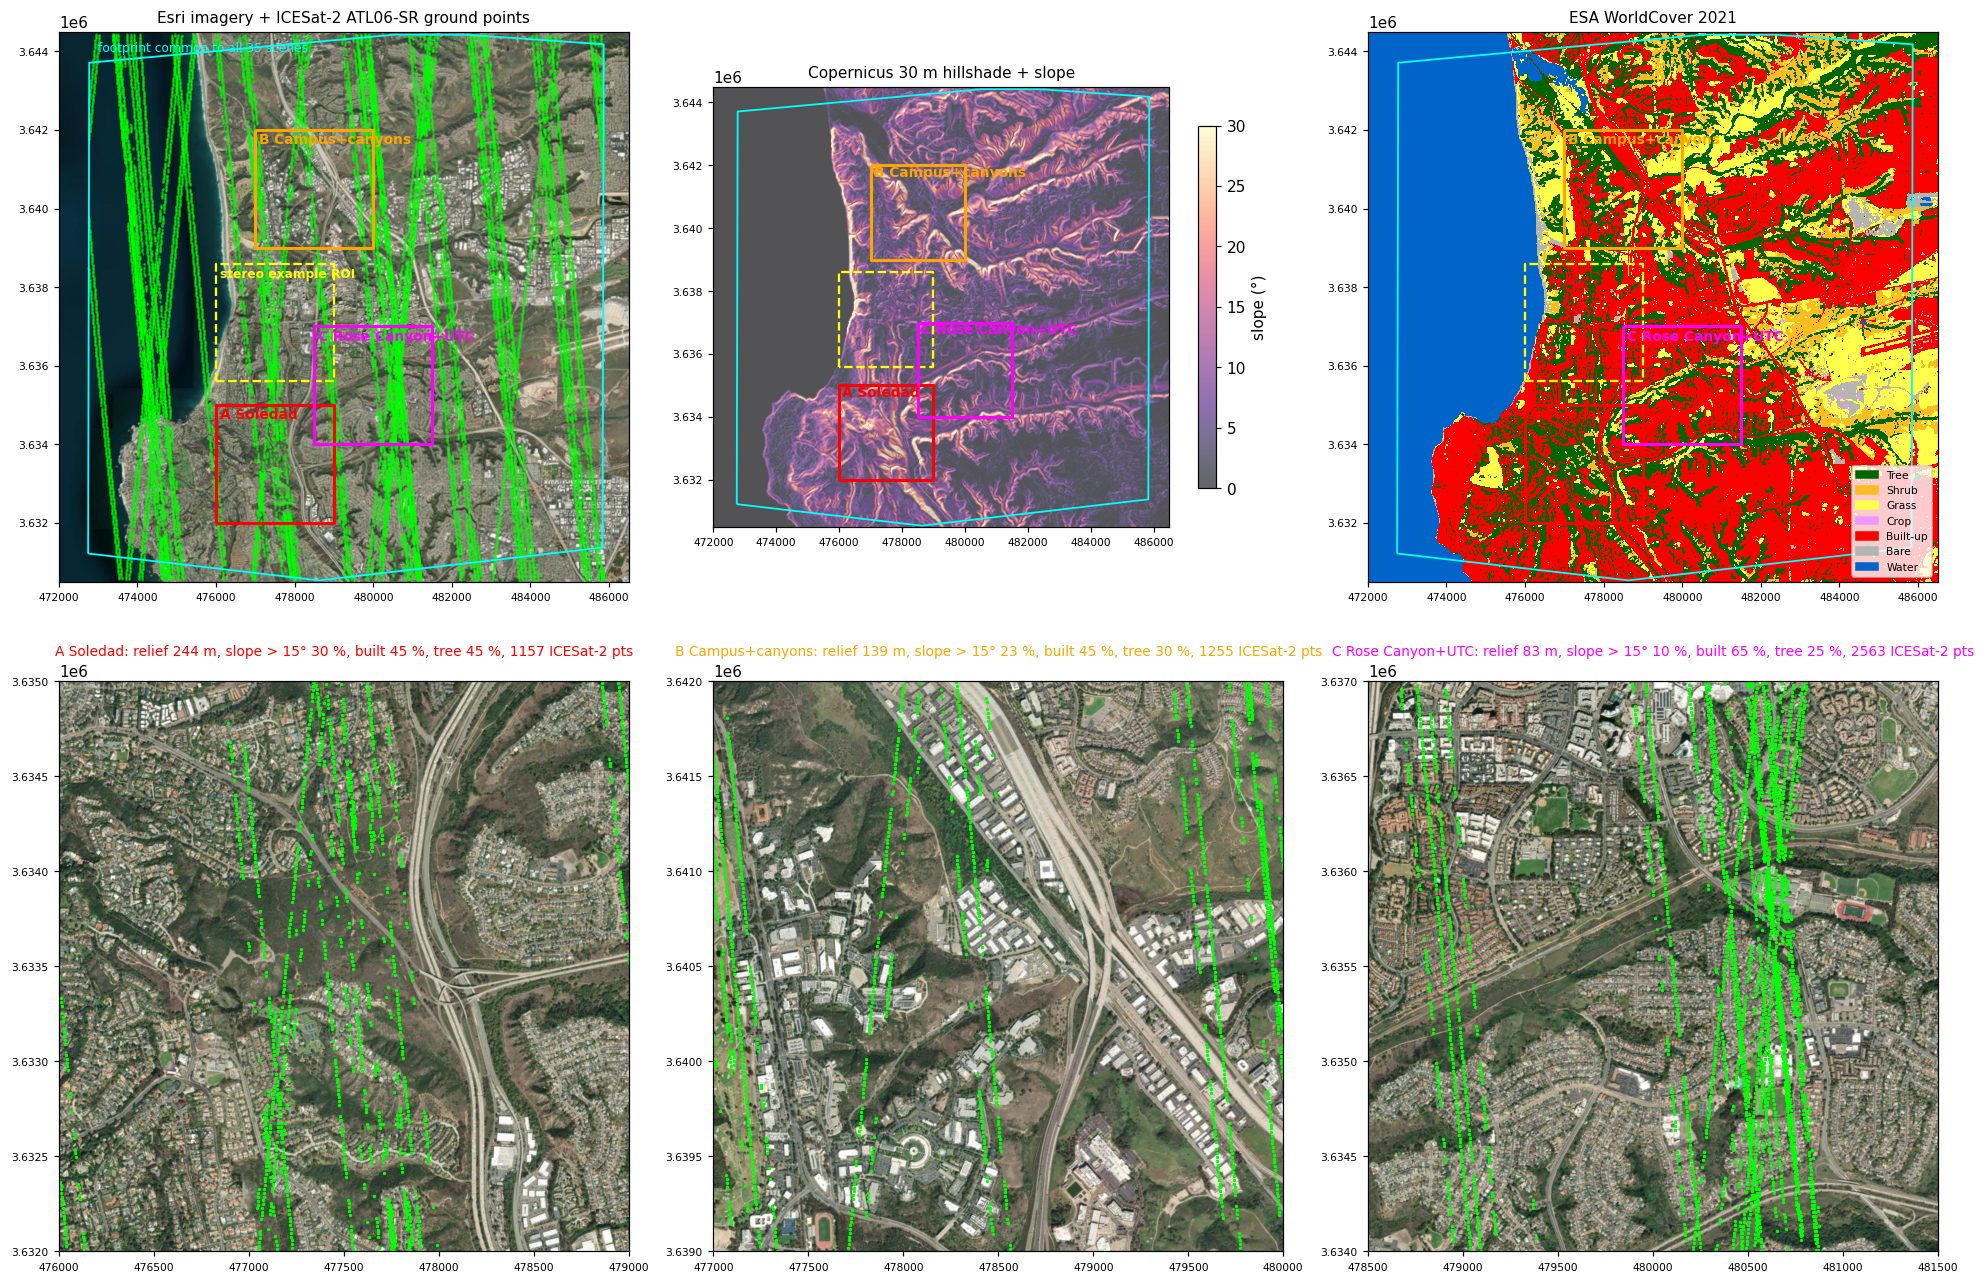

In [8]:
import warnings

import contextily as ctx
import geopandas as gpd
import rasterio
from matplotlib.colors import BoundaryNorm, LightSource, ListedColormap
from matplotlib.patches import Patch
from rasterio.windows import from_bounds
from shapely.geometry import box

warnings.filterwarnings("ignore")
ucsd = os.path.expanduser("~/Desktop/asp-plot-examples/ucsd_mvs/")
sel = f"{ucsd}selection/"

cands = gpd.read_file(f"{sel}candidates.geojson").to_crs(32611)
cands["crop"] = cands["name"]
inter = gpd.read_file(f"{sel}inter35_utm.geojson")  # footprint common to all 35 scenes
old_roi = gpd.GeoSeries([box(476000, 3635600, 479000, 3638600)], crs=32611)  # the stereo example's ROI
pts = gpd.read_parquet(f"{sel}atl06sr_inter35_ground.parquet").to_crs(32611)

with rasterio.open(f"{sel}cop30_ucsd_wgs84_utm.tif") as src:
    z = src.read(1).astype(float)
    z[z == src.nodata] = np.nan
    zext = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    res = src.res[0]
dzdx, dzdy = np.gradient(z, res)
slope = np.degrees(np.arctan(np.hypot(dzdx, dzdy)))
hs = LightSource(315, 45).hillshade(np.nan_to_num(z, nan=0), vert_exag=2, dx=res, dy=res)
with rasterio.open(f"{sel}worldcover_utm.tif") as src:
    wc = src.read(1)
    wext = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
wc_names = {10: "Tree", 20: "Shrub", 30: "Grass", 40: "Crop", 50: "Built-up", 60: "Bare", 80: "Water"}
wc_cols = {10: "#006400", 20: "#ffbb22", 30: "#ffff4c", 40: "#f096ff", 50: "#fa0000", 60: "#b4b4b4", 80: "#0064c8"}
codes = sorted(wc_names)
wc_cmap = ListedColormap([wc_cols[c] for c in codes])
wc_norm = BoundaryNorm([c - 5 for c in codes] + [codes[-1] + 5], wc_cmap.N)

colors = dict(zip(cands["crop"], ["red", "orange", "magenta"]))
fig, axes = plt.subplots(2, 3, figsize=(18, 12), dpi=110)
top = axes[0]
for ax in top:
    ax.set_xlim(472000, 486500)
    ax.set_ylim(3630500, 3644500)
    ax.tick_params(labelsize=7)
ctx.add_basemap(top[0], crs="EPSG:32611", source=ctx.providers.Esri.WorldImagery, attribution=False)
pts.plot(ax=top[0], markersize=0.3, color="lime", alpha=0.5)
top[0].set_title("Esri imagery + ICESat-2 ATL06-SR ground points", fontsize=10)
top[1].imshow(hs, extent=zext, cmap="gray")
im = top[1].imshow(slope, extent=zext, cmap="magma", alpha=0.6, vmin=0, vmax=30)
plt.colorbar(im, ax=top[1], shrink=0.6, label="slope (°)")
top[1].set_title("Copernicus 30 m hillshade + slope", fontsize=10)
top[2].imshow(wc, extent=wext, cmap=wc_cmap, norm=wc_norm, interpolation="nearest")
top[2].set_title("ESA WorldCover 2021", fontsize=10)
top[2].legend(handles=[Patch(color=wc_cols[c], label=wc_names[c]) for c in codes], loc="lower right", fontsize=7)
for ax in top:
    inter.boundary.plot(ax=ax, color="cyan", lw=1.2)
    old_roi.boundary.plot(ax=ax, color="yellow", lw=1.5, ls="--")
    for _, r in cands.iterrows():
        gpd.GeoSeries([r.geometry]).boundary.plot(ax=ax, color=colors[r.crop], lw=2)
        ax.text(r.geometry.bounds[0] + 100, r.geometry.bounds[3] - 350, r.crop, color=colors[r.crop], fontsize=9, weight="bold")
top[0].text(476100, 3638250, "stereo example ROI", color="yellow", fontsize=8, weight="bold")
top[0].text(473000, 3644000, "footprint common to all 35 scenes", color="cyan", fontsize=8)
stats_c = pd.read_csv(f"{sel}candidates_stats.csv").set_index("crop")
for ax, (_, r) in zip(axes[1], cands.iterrows()):
    b = r.geometry.bounds
    ax.set_xlim(b[0], b[2])
    ax.set_ylim(b[1], b[3])
    ax.tick_params(labelsize=7)
    ctx.add_basemap(ax, crs="EPSG:32611", source=ctx.providers.Esri.WorldImagery, attribution=False, zoom=16)
    pts[pts.within(r.geometry)].plot(ax=ax, markersize=1.5, color="lime")
    s = stats_c.loc[r.crop]
    ax.set_title(
        f"{r.crop}: relief {s.zmax - s.zmin:.0f} m, slope > 15° {s.pct_slope_gt15:.0f} %, "
        f"built {s.built:.0f} %, tree {s.tree:.0f} %, {s.n_is2:.0f} ICESat-2 pts",
        fontsize=9, color=colors[r.crop],
    )
fig.tight_layout()

**Scenes.** Five of the 35 are chosen to mirror the Atlanta design — a spread of weak and strong pairs, and candidate reference scenes with very different stars — while holding the season: the twelve scenes between 2014-10-27 and 2015-02-24 all have the sun 30–43° up. Pairwise convergence comes from the metadata alone (`get_convergence_angle`, as in the scene-selection notebooks); this set's ten pairs span 8–34°, since pairs above ~40° stop looking alike and fail to match.

| Name | CATID | date | off-nadir | azimuth | sun el. | role |
|---|---|---|---|---|---|---|
| nadir | `104001000496A100` | 2014-11-09 | 1.1° | 185° | 38° | reference of the first multi-view run; star 9 / 15 / 17 / 26° |
| n15 | `10400100047BBB00` | 2014-11-28 | 14.7° | 173° | 34° | |
| n24 | `10400100057DD500` | 2014-12-23 | 24.1° | 132° | 30° | reference of the second run; star 17 / 25 / 26 / 34° |
| n16 | `10400100071D8800` | 2015-01-24 | 16.3° | 199° | 34° | |
| n08 | `1040010007A93700` | 2015-02-12 | 8.4° | 268° | 40° | reference of the third run; star 9 / 17 / 19 / 34° (the left image of the stereo example's pair) |

Two of the ten pairs are weak on purpose — n15-n16 at 8.0° and nadir-n08 at 9.2°, the counterparts of Atlanta's 5° pairs — so that the median and exclusion blends have something to exclude. Temporal baselines run from 19 to 96 days.

star of reference nadir: [9, 15, 17, 26]
star of reference   n15: [8, 15, 17, 19]
star of reference   n24: [17, 25, 26, 34]
star of reference   n16: [8, 17, 17, 25]
star of reference   n08: [9, 17, 19, 34]


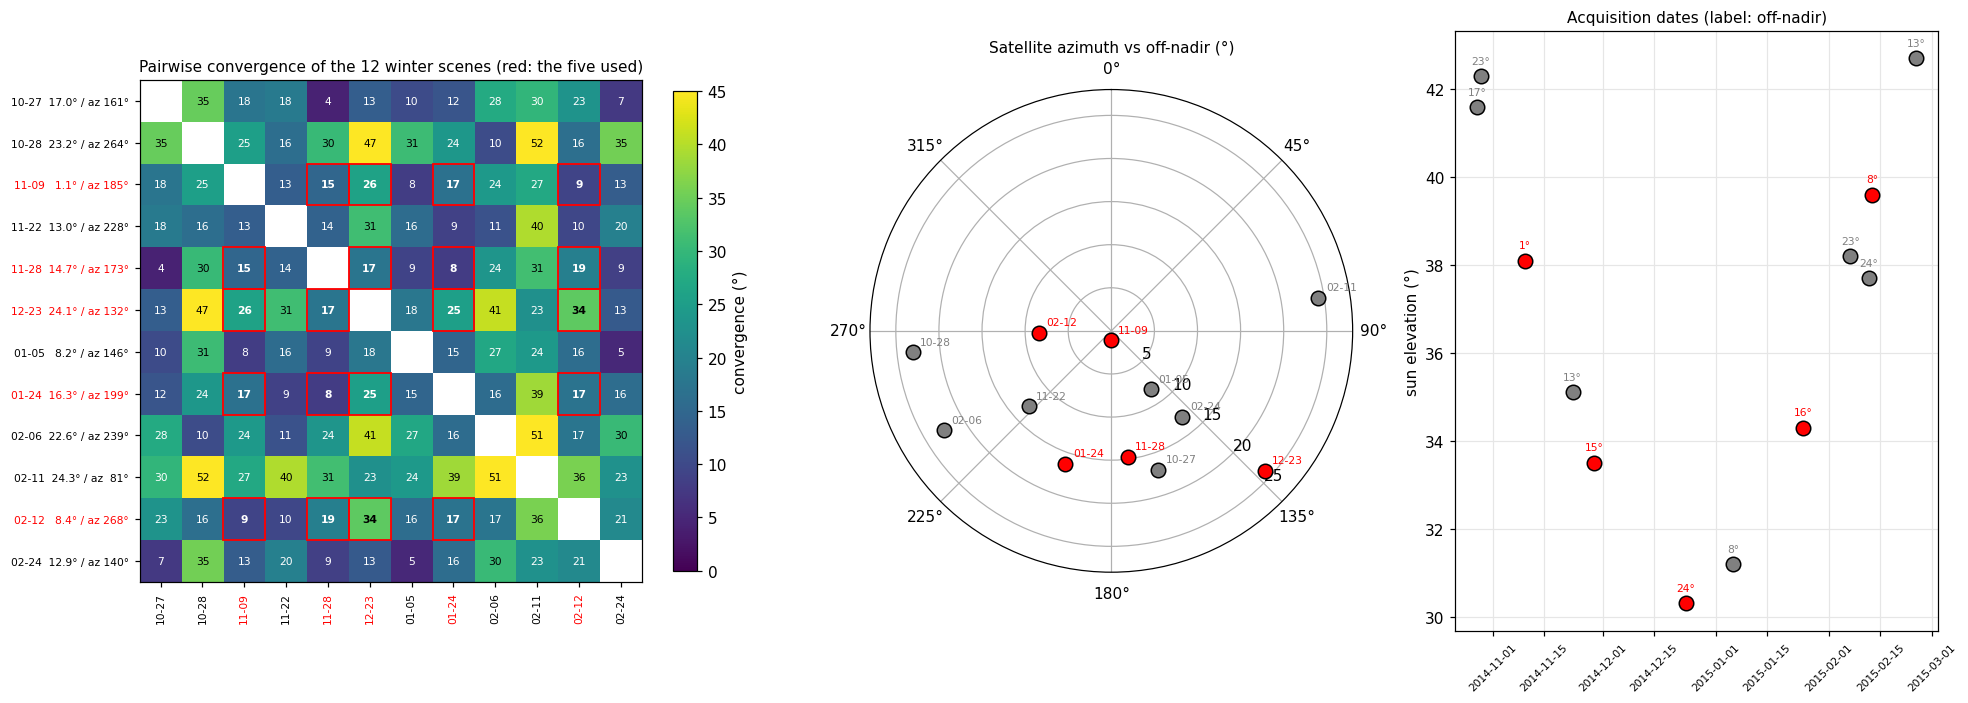

In [9]:
from itertools import combinations

from asp_plot.stereopair_metadata_parser import get_convergence_angle

winter = pd.read_csv(f"{sel}winter12.csv", parse_dates=["date"]).sort_values("date").reset_index(drop=True)
n = len(winter)
conv12 = np.full((n, n), np.nan)
for i, j in combinations(range(n), 2):
    a, b = winter.iloc[i], winter.iloc[j]
    conv12[i, j] = conv12[j, i] = get_convergence_angle(a.sat_az, a.sat_el, b.sat_az, b.sat_el)
chosen = ["104001000496A100", "10400100047BBB00", "10400100057DD500", "10400100071D8800", "1040010007A93700"]
sel_idx = [winter.index[winter.catid == c][0] for c in chosen]
short = {"104001000496A100": "nadir", "10400100047BBB00": "n15", "10400100057DD500": "n24", "10400100071D8800": "n16", "1040010007A93700": "n08"}

fig = plt.figure(figsize=(18, 6.5), dpi=110)
gs = fig.add_gridspec(1, 3, width_ratios=[1.3, 1, 1])
ax = fig.add_subplot(gs[0])
im = ax.imshow(conv12, cmap="viridis", vmin=0, vmax=45)
for i in range(n):
    for j in range(n):
        if i != j:
            ax.text(j, i, f"{conv12[i, j]:.0f}", ha="center", va="center", fontsize=7,
                    color="w" if conv12[i, j] < 30 else "k", weight="bold" if (i in sel_idx and j in sel_idx) else None)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_yticklabels([f"{r.date:%m-%d}  {r.off_nadir:4.1f}° / az {r.sat_az:3.0f}°" for r in winter.itertuples()], fontsize=7)
ax.set_xticklabels([f"{r.date:%m-%d}" for r in winter.itertuples()], rotation=90, fontsize=7)
for i in sel_idx:
    ax.get_yticklabels()[i].set_color("red"); ax.get_xticklabels()[i].set_color("red")
    for j in sel_idx:
        if i != j:
            ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=False, ec="red", lw=1.2))
plt.colorbar(im, ax=ax, shrink=0.8, label="convergence (°)")
ax.set_title("Pairwise convergence of the 12 winter scenes (red: the five used)", fontsize=10)
ax = fig.add_subplot(gs[1], projection="polar")
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
for i, r in winter.iterrows():
    c = "red" if i in sel_idx else "gray"
    ax.scatter(np.radians(r.sat_az), r.off_nadir, s=90, c=c, edgecolor="k", zorder=3)
    ax.annotate(f"{r.date:%m-%d}", (np.radians(r.sat_az), r.off_nadir), textcoords="offset points", xytext=(5, 5), fontsize=7, color=c)
ax.set_rmax(28); ax.set_rlabel_position(135)
ax.set_title("Satellite azimuth vs off-nadir (°)", fontsize=10)
ax = fig.add_subplot(gs[2])
for i, r in winter.iterrows():
    c = "red" if i in sel_idx else "gray"
    ax.scatter(r.date, r.sun_el, s=90, c=c, edgecolor="k", zorder=3)
    ax.annotate(f"{r.off_nadir:.0f}°", (r.date, r.sun_el), textcoords="offset points", xytext=(0, 8), fontsize=7, ha="center", color=c)
ax.set_ylabel("sun elevation (°)"); ax.set_title("Acquisition dates (label: off-nadir)", fontsize=10)
ax.tick_params(axis="x", rotation=45, labelsize=7); ax.grid(color="0.9")
fig.tight_layout()

conv_ucsd = {}
for a, b in combinations(chosen, 2):
    i, j = winter.index[winter.catid == a][0], winter.index[winter.catid == b][0]
    conv_ucsd[f"{short[a]}-{short[b]}"] = conv12[i, j]
for ref in chosen:
    star = sorted(round(conv_ucsd.get(f"{short[ref]}-{short[o]}", conv_ucsd.get(f"{short[o]}-{short[ref]}"))) for o in chosen if o != ref)
    print(f"star of reference {short[ref]:>5}: {star}")

### Processing

The Atlanta settings again — `asp_mgm`, `--subpixel-mode 9`, `affineepipolar`, one `bundle_adjust` of the five full scenes, `point2dem --errorimage` — at **1.2 m**, about four times the GSD as 1.9 m was for WorldView-2. WorldView-3 needs no `wv_correct`. Every scene is cropped with `--left-image-crop-win`, the window found by projecting the crop through each scene's RPC at −40 and +220 m so that relief cannot slide it off target.

| Run | Products |
|---|---|
| `bundle_adjust`, five full scenes jointly | `cropA/ba/run` |
| five scenes referenced on **nadir**, on **n24** and on **n08** | `stereo_mvs/`, `stereo_mvs_ref24/`, `stereo_mvs_ref08/` |
| the ten pairs | `stereo_pair_01_02` … `stereo_pair_04_05` |
| `dem_mosaic` of all ten (default average, median) and of the eight pairs above 15° (default, median) | `pairwise_mosaic-*`, `pairwise_wide8_mosaic-*` |

### Scoring, and the ICESat-2 pass that was a cloud

The ICESat-2 sample is requested once over the crop A footprint (1 015 points on twelve passes) and replayed for every DEM. **One whole pass, RGT 585 cycle 20, is a marine-layer cloud return 150–210 m above the ground**, 21 % of the sample; a mean ± 3σ cut cannot remove it, because that many points 175 m out inflate σ to 70 m. The benchmark's gross-outlier gate (points more than 30 NMAD from the median, dropped before the 3σ cut) exists for this, and leaves 650–760 points per DEM. The pre-alignment median is **+11 m for every DEM** — the five-scene `bundle_adjust` with no ground control settled the whole block 11 m low — a bias `pc_align` removes identically for all, so again the post-alignment NMAD ranks the candidates.

In [10]:
scenes_u = pd.read_csv(f"{ucsd}cropA/scenes.tsv", sep="\t", names=["idx", "image", "camera"], dtype=str)
idx_of = {r.image: r.idx for r in scenes_u.itertuples()}
pairs_u = pd.read_csv(f"{ucsd}cropA/pairs.tsv", sep="\t", names=["left", "right", "conv", "bh"])

candidates_u = {}
conv_of_u = {}
for r in pairs_u.sort_values("conv").itertuples():
    i, j = sorted([idx_of[r.left], idx_of[r.right]])
    name = f"{short[r.left[:16]]}-{short[r.right[:16]]}"
    candidates_u[f"pair {name} ({r.conv:.1f}°)"] = f"{ucsd}cropA/stereo_pair_{i}_{j}/run-DEM.tif"
    conv_of_u[name] = r.conv
candidates_u.update(
    {
        "10 pairs + mosaic": f"{ucsd}cropA/pairwise_mosaic-DEM.tif",
        "10 pairs + median mosaic": f"{ucsd}cropA/pairwise_mosaic-tile-0-median.tif",
        "8 pairs > 15° + mosaic": f"{ucsd}cropA/pairwise_wide8_mosaic-DEM.tif",
        "8 pairs > 15° + median mosaic": f"{ucsd}cropA/pairwise_wide8_mosaic-tile-0-median.tif",
        "MVS 5 ref nadir": f"{ucsd}cropA/stereo_mvs/run-DEM.tif",
        "MVS 5 ref n24": f"{ucsd}cropA/stereo_mvs_ref24/run-DEM.tif",
        "MVS 5 ref n08": f"{ucsd}cropA/stereo_mvs_ref08/run-DEM.tif",
    }
)
existing_u = {k: v for k, v in candidates_u.items() if os.path.exists(v)}
pending_u = [k for k in candidates_u if k not in existing_u]
print(f"{len(existing_u)} of {len(candidates_u)} candidates on disk; pending: {pending_u}\n")

bench_u = DEMBenchmark(
    directory=f"{ucsd}cropA",
    dems=existing_u,
    parquet=f"{ucsd}cropA/atl06sr_all.parquet",
    reference="MVS 5 ref nadir",
    title="UCSD WV3 winter 2014-15, crop A (Mount Soledad): multi-date scene combinations",
)
stats_u = bench_u.run()
stats_u.drop(columns=["dem_fn", "gsd_m", "north_shift_m", "east_shift_m", "down_shift_m"]).round(2)

17 of 17 candidates on disk; pending: []


=== [1/17] pair n15-n16 (8.0°): /Users/ben/Desktop/asp-plot-examples/ucsd_mvs/cropA/stereo_pair_02_04/run-DEM.tif


Reusing ICESat-2 ATL06-SR points for 'all' from: /Users/ben/Desktop/asp-plot-examples/ucsd_mvs/cropA/atl06sr_all.parquet
Filtering ATL06-SR all


  Outlier filter (3σ): all 1015 → 766 (removed 249)
  744 altimetry points: median +11.80 m, NMAD 1.61 m
  Reusing pc_align output in /Users/ben/Desktop/asp-plot-examples/ucsd_mvs/cropA/dem_benchmark/pair_n15-n16_8.0/pc_align

Writing out: /Users/ben/Desktop/asp-plot-examples/ucsd_mvs/cropA/dem_benchmark/pair_n15-n16_8.0/run-DEM_pc_align_translated.tif



  after pc_align (|t| = 11.82 m): median -0.08 m, NMAD 1.47 m



=== [2/17] pair nadir-n08 (9.2°): /Users/ben/Desktop/asp-plot-examples/ucsd_mvs/cropA/stereo_pair_01_05/run-DEM.tif


...


=== [17/17] MVS 5 ref n08: /Users/ben/Desktop/asp-plot-examples/ucsd_mvs/cropA/stereo_mvs_ref08/run-DEM.tif


Reusing ICESat-2 ATL06-SR points for 'all' from: /Users/ben/Desktop/asp-plot-examples/ucsd_mvs/cropA/atl06sr_all.parquet
Filtering ATL06-SR all
  Outlier filter (3σ): all 1015 → 774 (removed 241)
  753 altimetry points: median +11.15 m, NMAD 1.63 m
  Reusing pc_align output in /Users/ben/Desktop/asp-plot-examples/ucsd_mvs/cropA/dem_benchmark/MVS_5_ref_n08/pc_align



Writing out: /Users/ben/Desktop/asp-plot-examples/ucsd_mvs/cropA/dem_benchmark/MVS_5_ref_n08/run-DEM_pc_align_translated.tif



  after pc_align (|t| = 11.23 m): median +0.12 m, NMAD 1.52 m


,label,valid_pct,valid_area_km2,ie_median_m,ie_nmad_m,n_points,dh_median_m,dh_nmad_m,dh_rmse_m,translation_m,dh_aligned_median_m,dh_aligned_nmad_m,dh_aligned_rmse_m,vs_ref_median_m,vs_ref_nmad_m
0,pair n15-n16 (8.0°),98.71,9.31,0.07,0.06,744,11.80,1.61,11.85,11.82,-0.08,1.47,2.07,-0.55,0.93
1,pair nadir-n08 (9.2°),97.12,9.16,0.06,0.06,714,11.75,1.71,11.88,11.68,-0.01,1.73,2.15,-0.61,0.86
2,pair n15-nadir (14.9°),96.75,9.13,0.07,0.06,718,10.79,1.95,10.79,11.08,-0.11,2.07,2.45,0.17,0.60
3,pair nadir-n16 (16.9°),94.52,8.92,0.12,0.11,701,11.46,1.63,11.61,11.69,-0.07,1.65,2.20,-0.32,0.63
4,pair n16-n08 (17.1°),96.89,9.14,0.07,0.06,740,10.93,1.74,10.91,10.97,-0.10,1.75,2.08,0.04,0.58
5,pair n15-n24 (17.5°),95.93,9.05,0.10,0.09,718,10.92,1.71,10.99,11.08,0.08,1.60,2.12,0.17,0.52
6,pair n15-n08 (19.4°),94.70,8.93,0.12,0.12,703,11.11,1.66,11.11,11.04,0.08,1.62,2.11,0.02,0.52
7,pair n24-n16 (25.3°),91.13,8.60,0.17,0.14,708,11.42,1.45,11.54,11.47,0.14,1.48,2.04,-0.23,0.60
8,pair nadir-n24 (25.9°),90.17,8.51,0.13,0.12,672,10.79,1.79,10.82,10.78,0.21,1.63,2.39,0.40,0.54
9,pair n24-n08 (33.9°),86.49,8.16,0.24,0.25,653,11.05,1.68,11.16,10.87,0.15,1.60,2.21,0.09,0.57


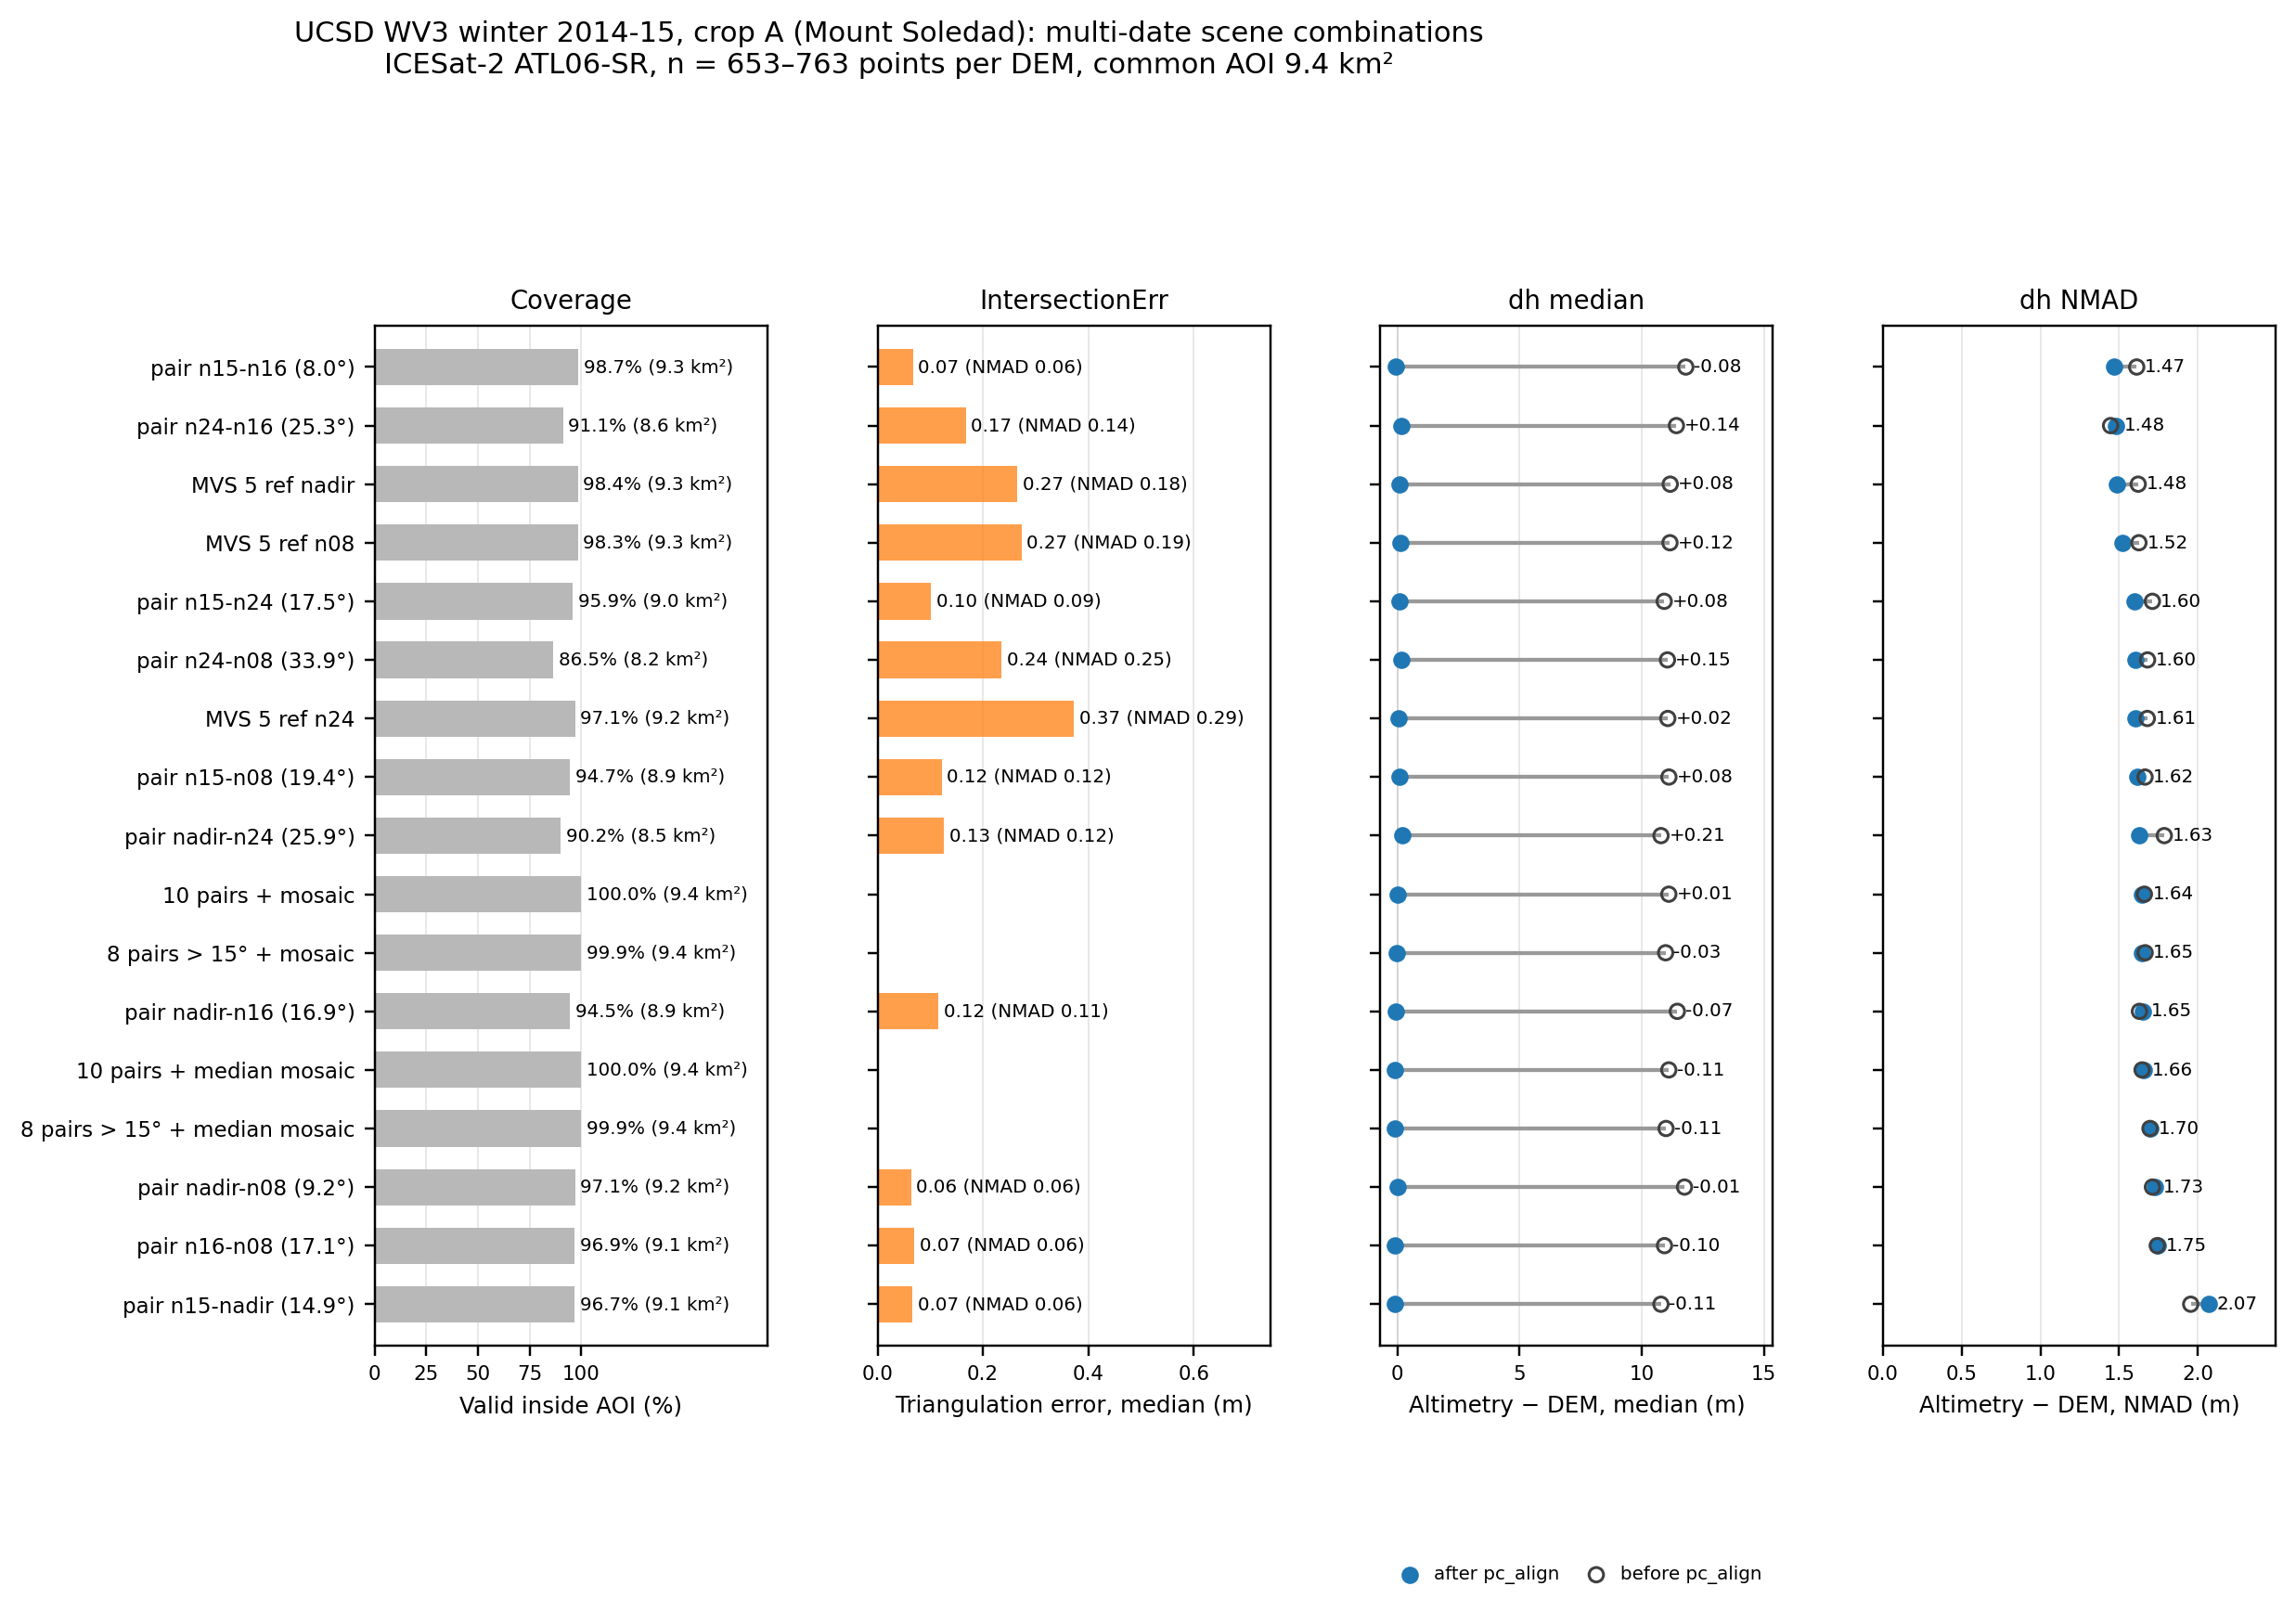

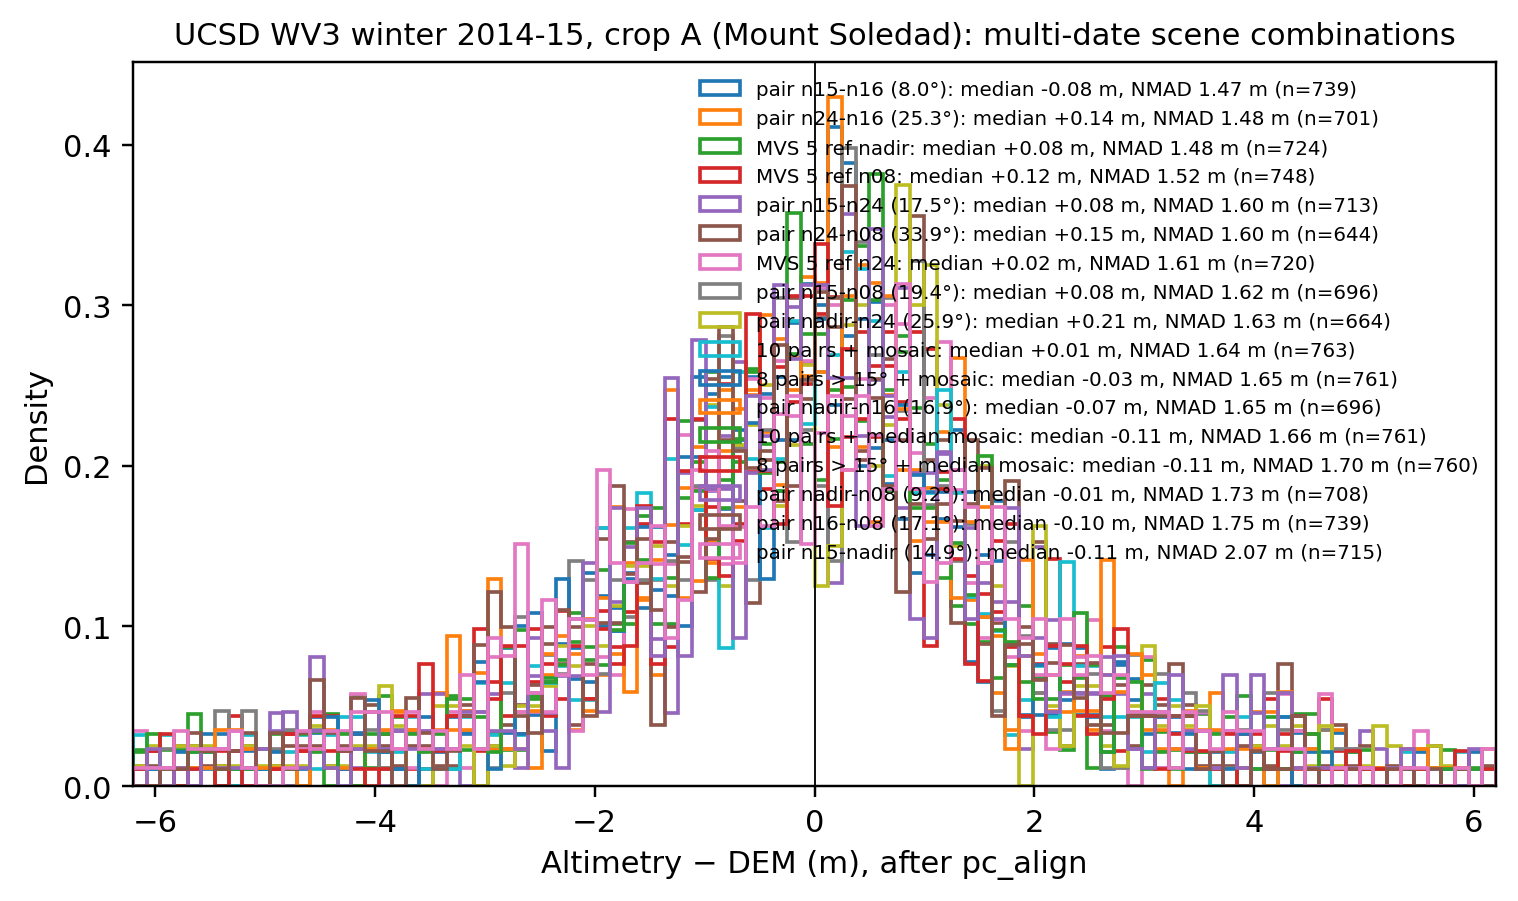

In [11]:
_ = bench_u.summary_plot()
_ = bench_u.histogram_plot()

Seventeen DEMs, and all but three land between 1.45 and 1.75 m. Most of the table is a tie, and that is itself the result: at this site the *choice of flow* is worth a tenth of a metre, where at Atlanta it was worth a factor of two.

The three that stand apart all contain the **nadir scene of 2014-11-09**: its pairs score 1.63, 1.65, 1.73 and 2.07 m, the worst four single pairs bar one, whatever their convergence. The five-scene run referenced on it still scores 1.48 m, because the other three rays outvote the bad one at every pixel. The hillshades below show what the numbers do not, coverage: the 25° pair leaves holes on the steep canyon walls it cannot see into, and the joint runs and the mosaic fill them.

The per-class breakdown (next cell) says the ranking is not an artefact of where the ICESat-2 tracks cross: tree points score 0.2–0.4 m worse than built-up points for every DEM, slope makes no consistent difference, and the n15-nadir pair is last in every class.

In [12]:
# NMAD of the aligned residuals by ESA WorldCover class and by slope, for every DEM,
# from the points each DEMBenchmark run already sampled.
from asp_plot.utils import nmad

with rasterio.open(f"{ucsd}cropA/stereo_mvs/run-DEM.tif") as src:
    zm = src.read(1).astype(float)
    zm[zm == src.nodata] = np.nan
    res_m = src.res[0]
    bounds_m, crs_m = src.bounds, src.crs
gx, gy = np.gradient(zm, res_m)
slope_m = np.degrees(np.arctan(np.hypot(gx, gy)))

def _slope_at(pts_df):
    p = pts_df.to_crs(crs_m)
    r = ((bounds_m.top - p.geometry.y.values) / res_m).astype(int)
    c = ((p.geometry.x.values - bounds_m.left) / res_m).astype(int)
    ok = (r >= 0) & (r < slope_m.shape[0]) & (c >= 0) & (c < slope_m.shape[1])
    out = np.full(len(p), np.nan)
    out[ok] = slope_m[r[ok], c[ok]]
    return out

wc_short = {10: "tree", 20: "shrub", 30: "grass", 50: "built"}
rows = []
for label, alt in bench_u.altimetry.items():
    p = alt.atl06sr_processing_levels_filtered["all"]
    dh = p["icesat_minus_aligned_dem"]
    lc = p["esa_worldcover.value"].map(wc_short)
    sl = _slope_at(p)
    ok = dh.notna().values
    rows.append(
        {
            "DEM": label,
            "all": nmad(dh[ok]),
            "built": nmad(dh[ok & (lc == "built").values]),
            "tree": nmad(dh[ok & (lc == "tree").values]),
            "slope ≤ 15°": nmad(dh[ok & (sl <= 15)]),
            "slope > 15°": nmad(dh[ok & (sl > 15)]),
        }
    )
by_class = pd.DataFrame(rows).set_index("DEM").sort_values("all")
p0 = next(iter(bench_u.altimetry.values())).atl06sr_processing_levels_filtered["all"]
print("points per class:", p0["esa_worldcover.value"].map(wc_short).value_counts().to_dict())
by_class.round(2)

points per class: {'tree': 350, 'built': 338, 'shrub': 54, 'grass': 24}


,all,built,tree,slope ≤ 15°,slope > 15°
DEM,,,,,
pair n15-n16 (8.0°),1.47,1.48,1.64,1.48,1.52
pair n24-n16 (25.3°),1.48,1.47,1.70,1.34,1.50
MVS 5 ref nadir,1.48,1.37,1.81,1.47,1.39
MVS 5 ref n08,1.52,1.43,1.80,1.46,1.52
pair n15-n24 (17.5°),1.60,1.54,1.88,1.62,1.45
pair n24-n08 (33.9°),1.60,1.53,1.82,1.59,1.59
MVS 5 ref n24,1.61,1.52,1.83,1.44,1.48
pair n15-n08 (19.4°),1.62,1.64,1.92,1.54,1.41
pair nadir-n24 (25.9°),1.63,1.64,1.96,1.56,1.73


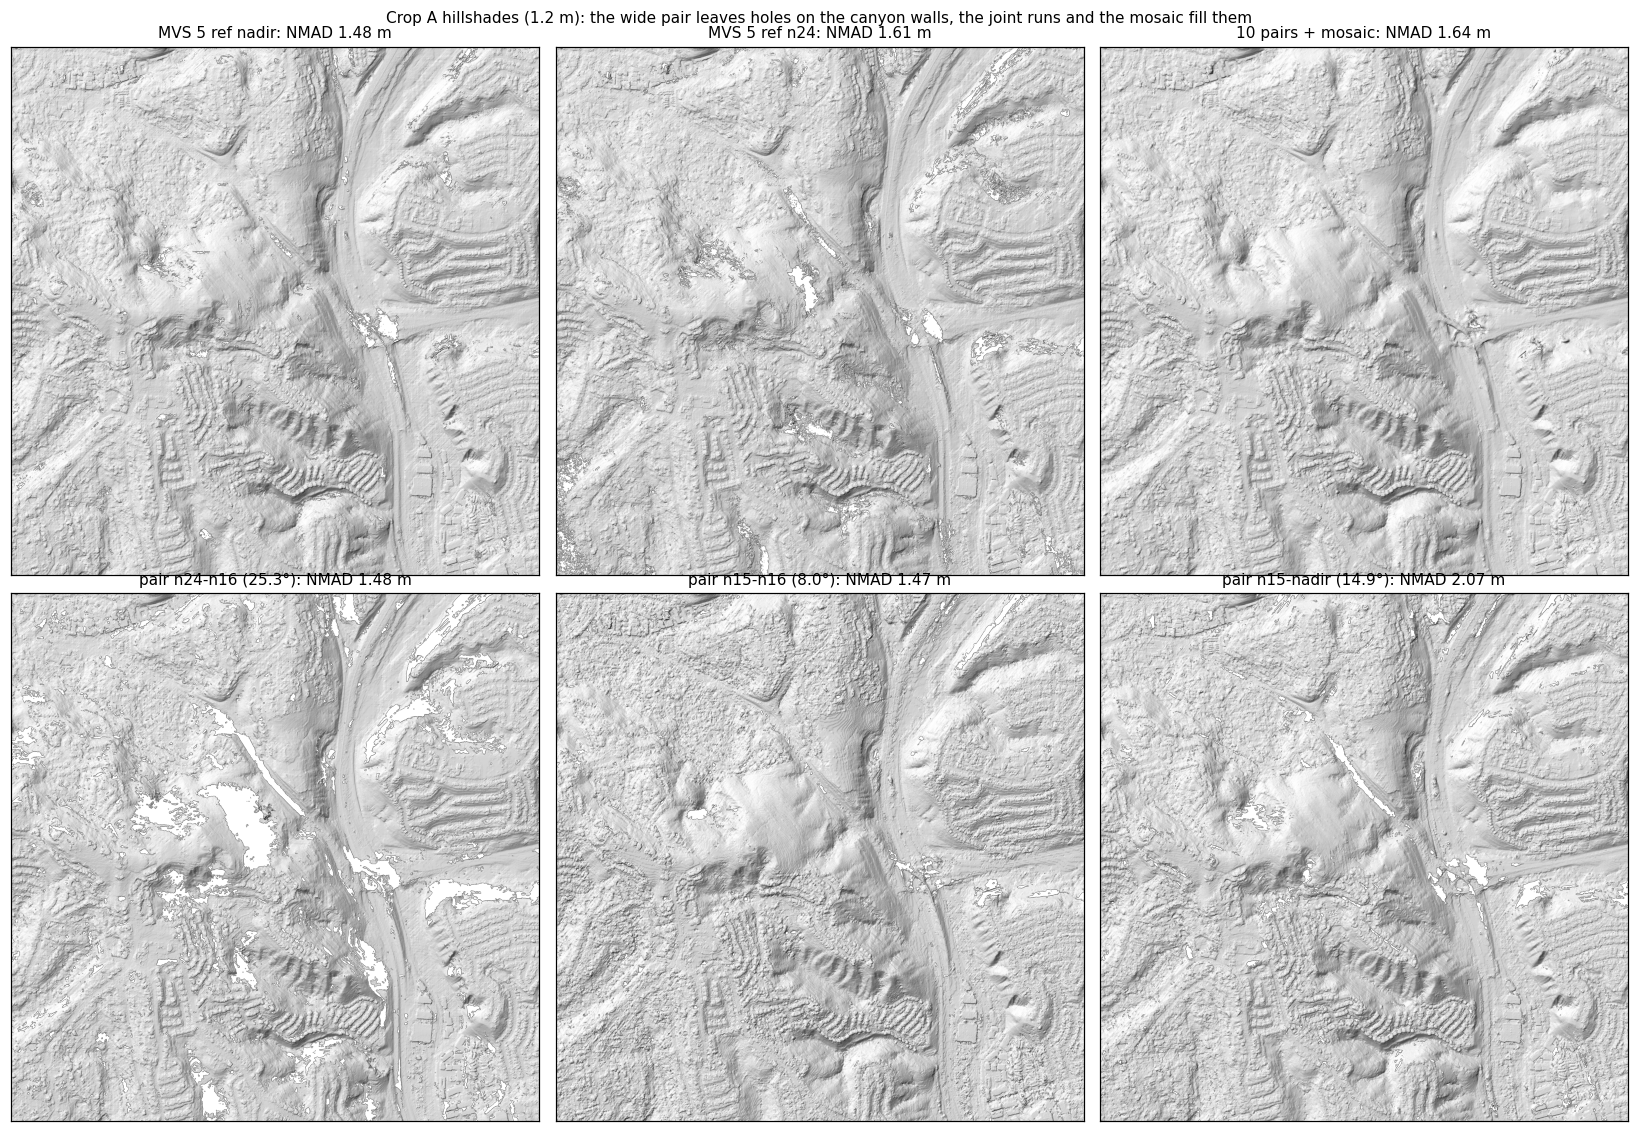

In [13]:
from matplotlib.colors import LightSource

panels = [
    ("MVS 5 ref nadir", "stereo_mvs/run-DEM.tif"),
    ("MVS 5 ref n24", "stereo_mvs_ref24/run-DEM.tif"),
    ("10 pairs + mosaic", "pairwise_mosaic-DEM.tif"),
    ("pair n24-n16 (25.3°)", "stereo_pair_03_04/run-DEM.tif"),
    ("pair n15-n16 (8.0°)", "stereo_pair_02_04/run-DEM.tif"),
    ("pair n15-nadir (14.9°)", "stereo_pair_01_02/run-DEM.tif"),
]
ls = LightSource(315, 45)
fig, axes = plt.subplots(2, 3, figsize=(15, 10.5), dpi=110)
for ax, (label, fn) in zip(axes.flat, panels):
    with rasterio.open(f"{ucsd}cropA/{fn}") as src:
        zz = src.read(1).astype(float)
        zz[zz == src.nodata] = np.nan
        ext = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
        r = src.res[0]
    hsd = ls.hillshade(np.nan_to_num(zz, nan=np.nanmean(zz)), vert_exag=1.5, dx=r, dy=r)
    hsd[np.isnan(zz)] = np.nan
    ax.imshow(hsd, extent=ext, cmap="gray")
    ax.set_xlim(476000, 479000); ax.set_ylim(3632000, 3635000)
    ax.set_title(f"{label}: NMAD {stats_u.set_index('label').loc[label, 'dh_aligned_nmad_m']:.2f} m", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Crop A hillshades (1.2 m): the wide pair leaves holes on the canyon walls, the joint runs and the mosaic fill them", fontsize=10)
fig.tight_layout()

---

## Two sites, the same axes

The Atlanta experiment answered its three questions with one curve and one mechanism. Put the UCSD pairs on the same convergence axis and neither survives unchanged.

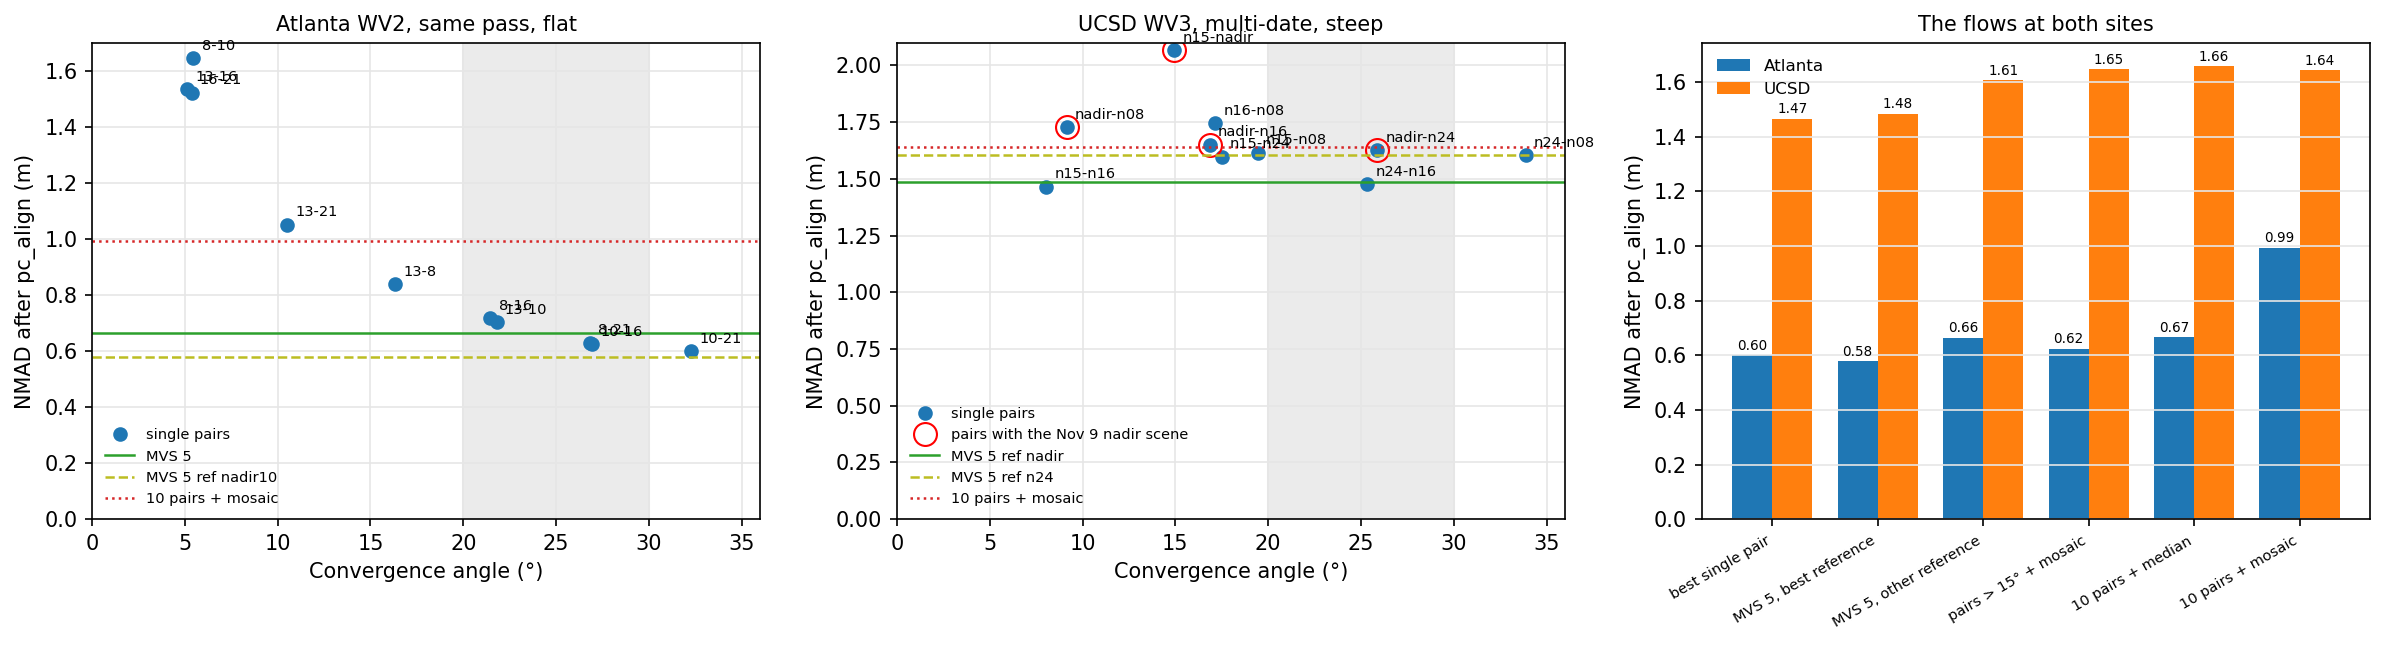

In [14]:
by_u = stats_u.set_index("label")
pairs_a = by[by.index.str.startswith("pair ")].copy()
pairs_a["convergence"] = [conv_of[lbl.split()[1]] for lbl in pairs_a.index]
pairs_b = by_u[by_u.index.str.startswith("pair ")].copy()
pairs_b["convergence"] = [conv_of_u[lbl.split()[1]] for lbl in pairs_b.index]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), dpi=150)
for ax, (site, pr, table, mvs_labels) in zip(
    axes[:2],
    (
        ("Atlanta WV2, same pass, flat", pairs_a.sort_values("convergence"), by, ["MVS 5", "MVS 5 ref nadir10"]),
        ("UCSD WV3, multi-date, steep", pairs_b.sort_values("convergence"), by_u, ["MVS 5 ref nadir", "MVS 5 ref n24"]),
    ),
):
    ax.axvspan(20, 30, color="0.92", zorder=0)
    ax.plot(pr["convergence"], pr["dh_aligned_nmad_m"], "o", color="tab:blue", label="single pairs")
    nadir_pairs = pr.index.str.contains("nadir")
    if nadir_pairs.any():
        ax.plot(pr["convergence"][nadir_pairs], pr["dh_aligned_nmad_m"][nadir_pairs], "o", mfc="none", mec="red", ms=11, label="pairs with the Nov 9 nadir scene")
    for c, v, lbl in zip(pr["convergence"], pr["dh_aligned_nmad_m"], pr.index):
        ax.annotate(lbl.split()[1], (c, v), textcoords="offset points", xytext=(4, 4), fontsize=7)
    for lbl, ls_, col in zip(mvs_labels, ("-", "--"), ("tab:green", "tab:olive")):
        if lbl in table.index:
            ax.axhline(table.loc[lbl, "dh_aligned_nmad_m"], ls=ls_, color=col, lw=1.2, label=lbl)
    ax.axhline(table.loc["10 pairs + mosaic", "dh_aligned_nmad_m"], ls=":", color="tab:red", lw=1.2, label="10 pairs + mosaic")
    ax.set_title(site, fontsize=10); ax.set_xlabel("Convergence angle (°)"); ax.set_ylabel("NMAD after pc_align (m)")
    ax.set_xlim(0, 36); ax.set_ylim(bottom=0); ax.grid(color="0.9"); ax.legend(fontsize=7, frameon=False)

# The flows, relative to the best single pair at each site
flows2 = [
    ("best single pair", "pair 10-21 (32.3°)", "pair n15-n16 (8.0°)"),
    ("MVS 5, best reference", "MVS 5 ref nadir10", "MVS 5 ref nadir"),
    ("MVS 5, other reference", "MVS 5", "MVS 5 ref n24"),
    ("pairs > 15° + mosaic", "6 pairs > 15° + mosaic", "8 pairs > 15° + mosaic"),
    ("10 pairs + median", "10 pairs + median mosaic", "10 pairs + median mosaic"),
    ("10 pairs + mosaic", "10 pairs + mosaic", "10 pairs + mosaic"),
]
ax = axes[2]
w = 0.38
for k, (site, table, off, col) in enumerate((("Atlanta", by, -w / 2, "tab:blue"), ("UCSD", by_u, w / 2, "tab:orange"))):
    vals = [table.loc[lbl[k + 1], "dh_aligned_nmad_m"] if lbl[k + 1] in table.index else np.nan for lbl in flows2]
    ax.bar(np.arange(len(flows2)) + off, vals, w, color=col, label=site)
    for x, v in zip(np.arange(len(flows2)) + off, vals):
        ax.text(x, v + 0.02, f"{v:.2f}", ha="center", fontsize=6.5)
ax.set_xticks(range(len(flows2))); ax.set_xticklabels([f[0] for f in flows2], rotation=30, ha="right", fontsize=7)
ax.set_ylabel("NMAD after pc_align (m)"); ax.set_title("The flows at both sites", fontsize=10); ax.legend(fontsize=8, frameon=False); ax.grid(axis="y", color="0.9")
fig.tight_layout()

---

## Takeaways, part 2 — what the second site changes

**Most of the UCSD ranking is inside the noise.** A paired block bootstrap that resamples whole ICESat-2 beam tracks instead of points cannot separate the top thirteen of the seventeen DEMs: the best DEM's 95 % interval is 1.1–1.8 m, its paired difference to the runner-up straddles zero (−0.07 to +0.17 m), and it ranks first in only 30 % of replicates. Residuals stay correlated for a few hundred metres along track, so some 700 points on 21 beam tracks resolve about ±0.3 m here, not the ±0.07 m that 700 independent points would. (The same test supports the Atlanta ranking.) The one robust result is that the 15° pair with the 2014-11-09 nadir scene (n15-nadir, 2.07 m) is clearly worse than the rest. Everything below is what the point estimates *suggest*.

**The convergence curve does not obviously carry over.** The 8° pair (1.47 m) ties the best 25° pair (1.48 m), and the 34° pair is no better than the 17° ones. The point estimates order the pairs by *which scene* is in them: the four pairs with the nadir scene are the worst bar one at every convergence. A plausible reading is that in steep, built-up, tree-covered terrain imaged on different days, matching — occlusion on canyon walls and house-lined slopes, and whatever changed on the ground between collects — limits a pair before its baseline does. Confirming that needs a denser altimetry sample or a DEM-to-DEM comparison.

**The reference-star rule may not generalise.** At Atlanta the widest star gave the best five-scene DEM (0.58 vs. 0.66 m, a difference the bootstrap supports). At UCSD the point estimates run the other way — nadir reference (star 9 / 15 / 17 / 26°) 1.48 m, 8° reference (9 / 17 / 19 / 34°) 1.52 m, 24° reference (17 / 25 / 26 / 34°) 1.61 m — but the three are within noise of each other. What holds at both sites: the mechanism is the same code path, the oblique reference sees the least of a steep crop (97.1 % coverage), and the reference is the choice that matters.

**No flow is distinguishably better than the joint triangulation.** The five-scene run referenced on the nadir scene (1.48 m) ties the best pair, and every blend of the ten pairs lands at 1.64–1.70 m; the direction agrees with Atlanta, but the 0.2 m gap is inside the interval. What the point estimates do argue against is exclusion by convergence angle, the fix that worked at Atlanta: here it would drop n15-n16 at 8°, the best-scoring DEM, and keep the four pairs with the nadir scene.

**Practical rules, revised** — what survives both sites:
1. The reference scene is the multi-view run's one real choice. Put the scene with the *best pairs* first, using the single pairs (`pairs.tsv` from the run) as the guide: at a same-pass site the end of the pass, at a multi-date site probably the cleanest, most nadir scene.
2. Do not filter pairs by convergence angle alone. Score the pairs and exclude by score, or use the joint triangulation, which needs no such decision.
3. `--median` remains the safe blend when pairs cannot be vetted, and IntersectionErr remains no guide to quality at either site.

**Caveats, part 2.** The second site is harder for every method (1.5 m against 0.6 m), so the differences between its flows are smaller and mostly unresolved by this sample; a denser altimetry sample, or scoring the DEMs against each other, would be needed to settle them. The nadir scene's weakness is observed, not explained: its pairs are last in every land-cover and slope class, so it is the scene and not a place, and a second nadir scene from the archive would separate the collect from the geometry. Temporal baseline (19–96 days) shows no visible pattern.